# Material-Agnostic Feature Fusion for Tool Condition Monitoring
**Coventry University — 7011CEM Individual Project**

This notebook implements and evaluates a domain-invariant hybrid CNN-LSTM framework for cross-material tool wear prediction. The pipeline trains on UCI Milling (cast iron and steel) and evaluates zero-shot and few-shot transfer to QIT-CEMC titanium machining data.

**Datasets:**
- UCI / NASA Milling (`mill.mat`): multi-case milling experiments, cast iron (material=1) and steel (material=2), six sensor channels
- QIT-CEMC Titanium: Ti6Al4V milling cycles, force/torque and vibration/acoustic channels, 67 matched pairs

**Models:**
- `CNNLSTMBaseline`: three-block CNN feature extractor followed by a two-layer LSTM regression head
- `MAFFModel`: same trunk with a `DomainInvariantFusion` module inserted between CNN and LSTM — channel attention gate followed by a bottleneck residual block

**Evaluation tiers:**
1. Cross-domain reliability: steel-trained models tested zero-shot on titanium
2. Signal ablation: counterfactual channel removal to identify material-invariant modalities
3. Operational latency: single-window inference time against 50 ms deployment constraint
4. Few-shot adaptation: 10-cycle titanium fine-tuning, evaluated on held-out 57 cycles

## 0. Environment Setup

In [45]:
import subprocess
subprocess.run(['pip', 'install', 'scipy', 'scikit-learn', 'openpyxl', 'xlrd', '--quiet'], check=True)

CompletedProcess(args=['pip', 'install', 'scipy', 'scikit-learn', 'openpyxl', 'xlrd', '--quiet'], returncode=0)

In [46]:
import os
import io
import copy
import math
import time
import random
import pickle
import zipfile
import warnings
import urllib.request
import numpy as np
import pandas as pd
import scipy.io as sio
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, IterableDataset

from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Configuration

In [47]:
MILL_MAT_PATH  = '/kaggle/working/mill.mat'
NASA_URL       = 'https://phm-datasets.s3.amazonaws.com/NASA/3.+Milling.zip'

QIT_CEMC_BASE  = '/kaggle/input/datasets/meenajaiswal/qit-dataset/Milling dataset from QIT'
QIT_LABEL_FILE = 'tool wear.xls'
QIT_FORCE_DIR  = 'Force and torque data'
QIT_VIB_DIR    = 'Vibration and sound data'

# Val includes case 8 (steel) and case 11 (cast iron) so checkpoint selection
# reflects mixed-material performance, matching the material diversity of the test set.
TRAIN_CASES = [1, 2, 3, 4, 5, 6, 7, 9, 10]
VAL_CASES   = [8, 11]
TEST_CASES  = [12, 15, 16]

# UCI case metadata for reference
# mat=1: cast iron   mat=2: steel
CASE_META = {
    1:  {'feed': 0.500, 'doc': 1.500, 'mat': 'cast_iron'},
    2:  {'feed': 0.500, 'doc': 0.750, 'mat': 'cast_iron'},
    3:  {'feed': 0.250, 'doc': 0.750, 'mat': 'cast_iron'},
    4:  {'feed': 0.250, 'doc': 1.500, 'mat': 'cast_iron'},
    5:  {'feed': 0.500, 'doc': 1.500, 'mat': 'steel'},
    6:  {'feed': 0.250, 'doc': 1.500, 'mat': 'steel'},
    7:  {'feed': 0.250, 'doc': 0.750, 'mat': 'steel'},
    8:  {'feed': 0.500, 'doc': 0.750, 'mat': 'steel'},
    9:  {'feed': 0.500, 'doc': 1.500, 'mat': 'cast_iron'},
    10: {'feed': 0.250, 'doc': 1.500, 'mat': 'cast_iron'},
    11: {'feed': 0.250, 'doc': 0.750, 'mat': 'cast_iron'},
    12: {'feed': 0.500, 'doc': 0.750, 'mat': 'cast_iron'},
    15: {'feed': 0.250, 'doc': 1.500, 'mat': 'steel'},
    16: {'feed': 0.500, 'doc': 1.500, 'mat': 'steel'},
}

WINDOW_SIZE  = 512
WINDOW_STEP  = 512
N_CHANNELS   = 3

BATCH_SIZE   = 32
NUM_EPOCHS   = 60
PATIENCE     = 15
LR_BASELINE  = 5e-4
LR_MAFF      = 3e-4
WEIGHT_DECAY = 1e-4

CNN_CHANNELS = [32, 64, 128]
LSTM_HIDDEN  = 128
LSTM_LAYERS  = 2
DROPOUT      = 0.3
FUSION_DIM   = 64

QIT_FINETUNE_N       = 10
QIT_FINETUNE_LR       = 5e-5
QIT_FINETUNE_PATIENCE = 3
QIT_FINETUNE_EPOCHS  = 20

print('Configuration loaded.')
print(f'Train cases : {TRAIN_CASES}')
print(f'Val cases   : {VAL_CASES}')
print(f'Test cases  : {TEST_CASES}')

Configuration loaded.
Train cases : [1, 2, 3, 4, 5, 6, 7, 9, 10]
Val cases   : [8, 11]
Test cases  : [12, 15, 16]


## 2. Data Loading

In [48]:
_local = Path('mill.mat')
if not Path(MILL_MAT_PATH).exists():
    if not _local.exists():
        print('Downloading NASA Milling zip...')
        with urllib.request.urlopen(NASA_URL) as resp:
            outer = zipfile.ZipFile(io.BytesIO(resp.read()))
        inner_bytes = outer.read('3. Milling/mill.zip')
        inner = zipfile.ZipFile(io.BytesIO(inner_bytes))
        inner.extract('mill.mat', path='.')
        print('mill.mat extracted.')
    MILL_MAT_PATH = str(_local)
else:
    print(f'mill.mat found at {MILL_MAT_PATH}')

mill.mat found at /kaggle/working/mill.mat


In [49]:
ALL_SIGNAL_COLS = ['smcAC', 'smcDC', 'vib_table', 'vib_spindle', 'AE_table', 'AE_spindle']
SIGNAL_CLIP     = 1000.0

def load_mill_mat(mat_path):
    raw  = sio.loadmat(mat_path)
    mill = raw['mill']
    records = []
    skipped = 0
    for i in range(mill.shape[1]):
        r      = mill[0, i]
        vb_val = float(r['VB'][0, 0])
        if np.isnan(vb_val):
            skipped += 1
            continue
        sig = np.column_stack([r[col].flatten() for col in ALL_SIGNAL_COLS]).astype(np.float32)
        if np.abs(sig).max() > SIGNAL_CLIP:
            skipped += 1
            continue
        records.append({
            'case':    int(r['case'][0, 0]),
            'run':     int(r['run'][0, 0]),
            'vb':      vb_val,
            'feed':    float(r['feed'][0, 0]),
            'doc':     float(r['DOC'][0, 0]),
            'mat':     int(r['material'][0, 0]),
            'signals': sig,
        })
    print(f'Loaded {len(records)} valid records, skipped {skipped}')
    return records

all_records = load_mill_mat(MILL_MAT_PATH)
vbs = [r['vb'] for r in all_records]
print(f'VB range: [{min(vbs):.3f}, {max(vbs):.3f}] mm')
print(f'Cases present: {sorted(set(r["case"] for r in all_records))}')

Loaded 145 valid records, skipped 22
VB range: [0.000, 1.530] mm
Cases present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


## 3. Exploratory Data Analysis

In [50]:
# Wear progression curves per case
# Confirms monotonic VB increase over run index — validates label integrity

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

cases_to_plot = [1, 2, 3, 4, 5, 7, 9, 11]
mat_colors = {'cast_iron': 'steelblue', 'steel': 'darkorange'}

for ax, case_id in zip(axes, cases_to_plot):
    case_recs = sorted([r for r in all_records if r['case'] == case_id],
                       key=lambda r: r['run'])
    runs = [r['run'] for r in case_recs]
    vbs_c = [r['vb'] for r in case_recs]
    meta = CASE_META.get(case_id, {})
    color = mat_colors.get(meta.get('mat', ''), 'grey')
    ax.plot(runs, vbs_c, marker='o', markersize=4, color=color, linewidth=1.5)
    ax.axhline(0.3, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    role = 'TRAIN'
    if case_id in VAL_CASES: role = 'VAL'
    if case_id in TEST_CASES: role = 'TEST'
    ax.set_title(f'Case {case_id} [{role}]\n{meta.get("mat","")} feed={meta.get("feed","")} DOC={meta.get("doc","")}',
                 fontsize=9)
    ax.set_xlabel('Run index')
    ax.set_ylabel('VB (mm)')
    ax.set_ylim(0, 0.85)

fig.suptitle('Tool wear progression per case — red dashed line at VB=0.3mm (ISO 8688 threshold)',
             fontsize=11)
plt.tight_layout()
plt.savefig('eda_wear_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_wear_curves.png')

Saved: eda_wear_curves.png


In [51]:
# Channel selection: smcDC, vib_table, AE_spindle
# Selection confirmed by prior Ridge LOOCV R2 = 0.4831 (best 3-channel combination)
UCI_KEEP_IDX   = [1, 2, 5]
CHANNEL_LABELS = ['smcDC / Fx', 'vib_table / AI1-01', 'AE_spindle / AI1-07']

for r in all_records:
    r['signals'] = r['signals'][:, UCI_KEEP_IDX]

print(f'Channels retained: {[ALL_SIGNAL_COLS[i] for i in UCI_KEEP_IDX]}')

Channels retained: ['smcDC', 'vib_table', 'AE_spindle']


In [52]:
# Raw signal comparison: example window from UCI (cast iron) vs UCI (steel)
# Illustrates within-dataset signal variation across materials

rec_ci = next(r for r in all_records if r['case'] == 3 and r['run'] == 8)   # cast iron, mid wear
rec_st = next(r for r in all_records if r['case'] == 7 and r['run'] == 4)   # steel, mid wear

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
t = np.arange(WINDOW_SIZE) / 1000.0  # 1 kHz sampling assumed

for col_idx, ch_name in enumerate(CHANNEL_LABELS):
    sig_ci = rec_ci['signals'][:WINDOW_SIZE, col_idx]
    sig_st = rec_st['signals'][:WINDOW_SIZE, col_idx]

    axes[0, col_idx].plot(t, sig_ci, color='steelblue', linewidth=0.6)
    axes[0, col_idx].set_title(f'Cast iron — {ch_name}\nCase 3 Run 8, VB={rec_ci["vb"]:.3f} mm')
    axes[0, col_idx].set_xlabel('Time (s)')

    axes[1, col_idx].plot(t, sig_st, color='darkorange', linewidth=0.6)
    axes[1, col_idx].set_title(f'Steel — {ch_name}\nCase 7 Run 4, VB={rec_st["vb"]:.3f} mm')
    axes[1, col_idx].set_xlabel('Time (s)')

for ax in axes.flatten():
    ax.set_ylabel('Amplitude (raw)')

fig.suptitle('Raw sensor signals: cast iron vs steel — UCI Milling dataset', fontsize=12)
plt.tight_layout()
plt.savefig('eda_raw_signals_uci.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_raw_signals_uci.png')

Saved: eda_raw_signals_uci.png


In [53]:
# Per-channel descriptive statistics by material

rows = []
for r in all_records:
    mat_label = 'cast_iron' if r['mat'] == 1 else 'steel'
    for ch_idx, ch_name in enumerate(CHANNEL_LABELS):
        sig = r['signals'][:, ch_idx]
        rows.append({
            'material': mat_label,
            'channel':  ch_name,
            'mean':     sig.mean(),
            'std':      sig.std(),
            'rms':      float(np.sqrt(np.mean(sig**2))),
        })

df_stats = pd.DataFrame(rows)
summary = df_stats.groupby(['material', 'channel'])[['mean', 'std', 'rms']].mean().round(4)
print('Per-channel statistics by material (mean across all records):')
print(summary.to_string())

Per-channel statistics by material (mean across all records):
                                 mean     std     rms
material  channel                                    
cast_iron AE_spindle / AI1-07  0.2627  0.0710  0.2727
          smcDC / Fx           5.9724  2.0450  6.3212
          vib_table / AI1-01   0.8201  0.3412  0.8896
steel     AE_spindle / AI1-07  0.1964  0.0566  0.2055
          smcDC / Fx           6.5414  2.1899  6.9087
          vib_table / AI1-01   0.9139  0.3694  0.9867


In [54]:
# Channel correlation heatmap — cast iron vs steel
# Different correlation structure between materials is evidence for the domain gap

def get_channel_matrix(records, mat_code):
    segs = [r['signals'] for r in records if r['mat'] == mat_code]
    return np.vstack(segs)

mat_ci = get_channel_matrix(all_records, 1)
mat_st = get_channel_matrix(all_records, 2)

corr_ci = np.corrcoef(mat_ci.T)
corr_st = np.corrcoef(mat_st.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
short_labels = ['smcDC', 'vib_table', 'AE_spindle']

for ax, corr, title in zip(axes,
                            [corr_ci, corr_st],
                            ['Cast iron (material=1)', 'Steel (material=2)']):
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(short_labels, rotation=30, ha='right')
    ax.set_yticklabels(short_labels)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=10)
    ax.set_title(f'Channel correlation — {title}')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('eda_channel_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_channel_correlation.png')

Saved: eda_channel_correlation.png


## 4. Preprocessing and Windowing

In [55]:
def segment_record(record, window_size, step):
    sig = record['signals']
    T   = sig.shape[0]
    windows = []
    start   = 0
    while start + window_size <= T:
        windows.append({
            'window': sig[start:start + window_size, :],
            'vb':     record['vb'],
            'case':   record['case'],
            'run':    record['run'],
        })
        start += step
    return windows

all_windows = []
for r in all_records:
    all_windows.extend(segment_record(r, WINDOW_SIZE, WINDOW_STEP))

print(f'Total windows : {len(all_windows)}')
print(f'Window shape  : {all_windows[0]["window"].shape}')

Total windows : 2465
Window shape  : (512, 3)


In [56]:
def split_by_cases(windows, case_list):
    return [w for w in windows if w['case'] in case_list]

train_windows = split_by_cases(all_windows, TRAIN_CASES)
val_windows   = split_by_cases(all_windows, VAL_CASES)
test_windows  = split_by_cases(all_windows, TEST_CASES)

cases_train = np.array([w['case'] for w in train_windows])
cases_val   = np.array([w['case'] for w in val_windows])
cases_test  = np.array([w['case'] for w in test_windows])
runs_train  = np.array([w['run']  for w in train_windows])
runs_val    = np.array([w['run']  for w in val_windows])
runs_test   = np.array([w['run']  for w in test_windows])

print(f'Train windows : {len(train_windows)}  ({len(set(zip(cases_train, runs_train)))} records)')
print(f'Val windows   : {len(val_windows)}  ({len(set(zip(cases_val,   runs_val)))} records)')
print(f'Test windows  : {len(test_windows)}  ({len(set(zip(cases_test,  runs_test)))} records)')

for vc in VAL_CASES:
    n = len(set((c, r) for c, r in zip(cases_val, runs_val) if c == vc))
    print(f'  Val case {vc} ({CASE_META[vc]["mat"]}): {n} records')

Train windows : 1343  (79 records)
Val windows   : 425  (25 records)
Test windows  : 357  (21 records)
  Val case 8 (steel): 5 records
  Val case 11 (cast_iron): 20 records


In [57]:
# Per-window z-score standardisation
# Applied independently per window to remove absolute amplitude differences
# between UCI (volts/dimensionless) and QIT (Newtons/m/s2/Pa) channels

def windows_to_array(windows):
    return np.stack([w['window'] for w in windows], axis=0)

def labels_to_array(windows):
    return np.array([w['vb'] for w in windows], dtype=np.float32)

def per_window_standardise_batch(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    std  = np.where(std < 1e-8, 1e-8, std)
    return ((X - mean) / std).astype(np.float32)

X_train = per_window_standardise_batch(windows_to_array(train_windows))
X_val   = per_window_standardise_batch(windows_to_array(val_windows))
X_test  = per_window_standardise_batch(windows_to_array(test_windows))

y_train = labels_to_array(train_windows)
y_val   = labels_to_array(val_windows)
y_test  = labels_to_array(test_windows)

print(f'X_train: {X_train.shape}  y range: [{y_train.min():.3f}, {y_train.max():.3f}]')
print(f'X_val  : {X_val.shape}    y range: [{y_val.min():.3f}, {y_val.max():.3f}]')
print(f'X_test : {X_test.shape}   y range: [{y_test.min():.3f}, {y_test.max():.3f}]')

X_train: (1343, 512, 3)  y range: [0.000, 0.810]
X_val  : (425, 512, 3)    y range: [0.000, 0.760]
X_test : (357, 512, 3)   y range: [0.050, 0.700]


## 5. QIT-CEMC Titanium Data Loader

In [58]:
def custom_sort_key(filename):
    parts = Path(filename).stem.split('-')
    try:
        return (int(parts[0]), int(parts[1]), int(parts[2]))
    except (IndexError, ValueError):
        return (0, 0, 0)

def file_match_key(filename):
    parts = Path(filename).stem.split('-')
    try:
        return (int(parts[0]), int(parts[1]), int(parts[2]))
    except (IndexError, ValueError):
        return None

def load_qit_labels(base_path, label_filename):
    label_path = Path(base_path) / label_filename
    df = pd.read_excel(label_path, header=None, skiprows=4)
    df.columns = range(df.shape[1])
    df = df.dropna(subset=[0])
    df[0] = df[0].astype(int)
    side_cols = [1, 4, 7, 10]
    for c in side_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['mean_vb'] = df[side_cols].mean(axis=1)
    return dict(zip(df[0].values, df['mean_vb'].values))

def per_window_standardise(w):
    mean = w.mean(axis=0, keepdims=True)
    std  = w.std(axis=0, keepdims=True)
    std  = np.where(std < 1e-8, 1e-8, std)
    return ((w - mean) / std).astype(np.float32)

def read_force_file(filepath):
    # Binary-level reader: splits on newlines in raw bytes, extracts column 1 (tab-separated),
    # skips any row where float conversion fails. No CSV parser involved — avoids expat
    # column-limit errors on large files and control-byte corruption in data values.
    with open(filepath, 'rb') as fh:
        raw_bytes = fh.read()
    lines  = raw_bytes.splitlines()
    values = []
    for line in lines[1:]:      # skip header
        parts = line.split(b'\t')
        if len(parts) < 2:
            continue
        try:
            values.append(float(parts[1]))
        except (ValueError, UnicodeDecodeError):
            continue
    return np.array(values, dtype=np.float32).reshape(-1, 1)

def build_qit_file_pairs(base_path, force_dir, vib_dir, label_filename):
    force_folder = Path(base_path) / force_dir
    vib_folder   = Path(base_path) / vib_dir

    force_files = sorted(
        [f for f in force_folder.iterdir() if f.suffix == '.txt'],
        key=lambda f: custom_sort_key(f.name)
    )
    vib_files = sorted(
        [f for f in vib_folder.iterdir() if f.suffix in ('.csv', '.xlsx')],
        key=lambda f: custom_sort_key(f.name)
    )
    vib_by_key = {}
    for vf in vib_files:
        k = file_match_key(vf.name)
        if k is not None:
            vib_by_key[k] = vf

    matched_pairs = []
    unmatched     = []
    for ff in force_files:
        k  = file_match_key(ff.name)
        vf = vib_by_key.get(k)
        if vf is None:
            unmatched.append(ff.name)
        else:
            matched_pairs.append((ff, vf))

    if unmatched:
        print(f'Force files with no vibration match (skipped): {unmatched}')

    cycle_to_vb = load_qit_labels(base_path, label_filename)
    pairs   = []
    skipped = 0
    for seq_idx, (ff, vf) in enumerate(matched_pairs, start=1):
        vb_val = cycle_to_vb.get(seq_idx)
        if vb_val is None or np.isnan(vb_val):
            skipped += 1
            continue
        pairs.append((ff, vf, float(vb_val)))

    print(f'Matched pairs : {len(matched_pairs)}')
    print(f'Usable pairs  : {len(pairs)} (skipped {skipped} missing labels)')
    vb_vals = [p[2] for p in pairs]
    print(f'VB range      : [{min(vb_vals):.4f}, {max(vb_vals):.4f}] mm')
    return pairs


class QITIterableDataset(IterableDataset):
    def __init__(self, file_pairs, window_size, step):
        self.file_pairs  = file_pairs
        self.window_size = window_size
        self.step        = step

    def __iter__(self):
        for ff, vf, vb_label in self.file_pairs:
            try:
                f_data = read_force_file(ff)
            except Exception as e:
                print(f'Force read error ({ff.name}): {e}')
                continue
    
            try:
                if vf.suffix == '.xlsx':
                    v_data = pd.read_excel(
                        vf, header=0, usecols=[1, 4]
                    ).values.astype(np.float32)
                else:
                    v_data = pd.read_csv(
                        vf, sep=',', header=0, usecols=[1, 4],
                        engine='c', encoding='latin-1',
                    ).values.astype(np.float32)
            except Exception:
                # Vib file unreadable by standard csv — fall back to byte reader on same file
                try:
                    with open(vf, 'rb') as fh:
                        raw = fh.read()
                    lines = raw.splitlines()
                    col1, col2 = [], []
                    for line in lines[1:]:
                        parts = line.split(b',')
                        if len(parts) < 5:
                            continue
                        try:
                            col1.append(float(parts[1]))
                            col2.append(float(parts[4]))
                        except (ValueError, UnicodeDecodeError):
                            continue
                    min_vib = min(len(col1), len(col2))
                    v_data = np.column_stack([
                        np.array(col1[:min_vib], dtype=np.float32),
                        np.array(col2[:min_vib], dtype=np.float32),
                    ])
                except Exception as e:
                    print(f'Vib read error ({vf.name}): {e}')
                    continue
    
            min_len = min(f_data.shape[0], v_data.shape[0])
            sig = np.column_stack([
                f_data[:min_len, 0],
                v_data[:min_len, 0],
                v_data[:min_len, 1],
            ])
            T     = sig.shape[0]
            start = 0
            while start + self.window_size <= T:
                w = sig[start:start + self.window_size, :]
                x = torch.from_numpy(per_window_standardise(w).T)
                y = torch.tensor([vb_label], dtype=torch.float32)
                yield x, y
                start += self.step


qit_file_pairs = build_qit_file_pairs(
    base_path=QIT_CEMC_BASE,
    force_dir=QIT_FORCE_DIR,
    vib_dir=QIT_VIB_DIR,
    label_filename=QIT_LABEL_FILE,
)
qit_dataset = QITIterableDataset(qit_file_pairs, WINDOW_SIZE, WINDOW_STEP)
qit_loader  = DataLoader(qit_dataset, batch_size=BATCH_SIZE, num_workers=0)

y_qit_labels = np.array([vb for _, _, vb in qit_file_pairs], dtype=np.float32)
print(f'QIT IterableDataset ready — {len(qit_file_pairs)} cycles')

Force files with no vibration match (skipped): ['01-26-2.txt']
Matched pairs : 67
Usable pairs  : 67 (skipped 0 missing labels)
VB range      : [0.0398, 0.4498] mm
QIT IterableDataset ready — 67 cycles


In [59]:
# VB label distribution: train / val / test / QIT titanium
# Visualises domain shift between source (UCI) and target (QIT) datasets

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(y_train,      bins=30, alpha=0.55, color='steelblue',
        label=f'Train UCI ({len(set(zip(cases_train, runs_train)))} records)')
ax.hist(y_test,       bins=20, alpha=0.55, color='darkorange',
        label=f'Test UCI ({len(set(zip(cases_test, runs_test)))} records)')
ax.hist(y_qit_labels, bins=20, alpha=0.55, color='forestgreen',
        label=f'QIT titanium ({len(y_qit_labels)} cycles)')

ax.set_xlabel('VB (mm)')
ax.set_ylabel('Count')
ax.set_title('VB label distribution by dataset split')
ax.legend()

plt.tight_layout()
plt.savefig('eda_vb_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_vb_distribution.png')

Saved: eda_vb_distribution.png


## 6. PyTorch Datasets and DataLoaders

In [60]:
class WearDataset(Dataset):
    def __init__(self, X, y, cases, runs):
        self.X     = torch.from_numpy(X.transpose(0, 2, 1))  # (N, C, W) for Conv1d
        self.y     = torch.from_numpy(y).unsqueeze(1)
        self.cases = torch.from_numpy(cases.astype(np.int32))
        self.runs  = torch.from_numpy(runs.astype(np.int32))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.cases[idx], self.runs[idx]


train_dataset = WearDataset(X_train, y_train, cases_train, runs_train)
val_dataset   = WearDataset(X_val,   y_val,   cases_val,   runs_val)
test_dataset  = WearDataset(X_test,  y_test,  cases_test,  runs_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 42
Val batches   : 14
Test batches  : 12


## 7. Model Architectures

### CNNLSTMBaseline
Three sequential CNN blocks (Conv1d → BatchNorm → ReLU → MaxPool) reduce the input sequence from 512 to 64 time steps while increasing channel depth from 3 to 128. The LSTM then encodes temporal wear progression across the compressed sequence. The final hidden state feeds a linear regression head.

### MAFFModel — Material-Agnostic Feature Fusion
Identical CNN trunk, but with a `DomainInvariantFusion` (DIF) module inserted between CNN and LSTM. The DIF module applies a channel-wise squeeze-excitation attention gate to weight feature channels by their estimated cross-material relevance, followed by a bottleneck residual block (128 → 64 → 128) that projects features into a lower-dimensional space and back, encouraging the model to retain only information that generalises across the steel–titanium domain boundary.

In [61]:
class CNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=pool),
        )

    def forward(self, x):
        return self.block(x)


class CNNLSTMBaseline(nn.Module):
    def __init__(self, n_channels, cnn_channels, lstm_hidden, lstm_layers, dropout):
        super().__init__()
        self.cnn = nn.Sequential(
            CNNBlock(n_channels,      cnn_channels[0]),
            CNNBlock(cnn_channels[0], cnn_channels[1]),
            CNNBlock(cnn_channels[1], cnn_channels[2]),
        )
        self.lstm = nn.LSTM(
            input_size=cnn_channels[-1],
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(lstm_hidden, 1)

    def forward(self, x):
        feat = self.cnn(x)
        feat = feat.permute(0, 2, 1)
        out, _ = self.lstm(feat)
        return self.head(self.dropout(out[:, -1, :]))


class ChannelAttention(nn.Module):
    def __init__(self, n_ch, reduction=4):
        super().__init__()
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(n_ch, max(n_ch // reduction, 8)),
            nn.ReLU(inplace=True),
            nn.Linear(max(n_ch // reduction, 8), n_ch),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.gate(x).unsqueeze(-1)


class DomainInvariantFusion(nn.Module):
    def __init__(self, in_ch, fusion_dim):
        super().__init__()
        self.attention  = ChannelAttention(in_ch)
        self.bottleneck = nn.Sequential(
            nn.Conv1d(in_ch, fusion_dim, kernel_size=1),
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(inplace=True),
        )
        self.expand = nn.Sequential(
            nn.Conv1d(fusion_dim, in_ch, kernel_size=1),
            nn.BatchNorm1d(in_ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        attended = self.attention(x)
        latent   = self.bottleneck(attended)
        expanded = self.expand(latent)
        return self.relu(x + expanded)


class MAFFModel(nn.Module):
    def __init__(self, n_channels, cnn_channels, fusion_dim, lstm_hidden, lstm_layers, dropout):
        super().__init__()
        self.cnn = nn.Sequential(
            CNNBlock(n_channels,      cnn_channels[0]),
            CNNBlock(cnn_channels[0], cnn_channels[1]),
            CNNBlock(cnn_channels[1], cnn_channels[2]),
        )
        self.dif  = DomainInvariantFusion(cnn_channels[-1], fusion_dim)
        self.lstm = nn.LSTM(
            input_size=cnn_channels[-1],
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(lstm_hidden, 1)

    def forward(self, x):
        feat = self.cnn(x)
        feat = self.dif(feat)
        feat = feat.permute(0, 2, 1)
        out, _ = self.lstm(feat)
        return self.head(self.dropout(out[:, -1, :]))


baseline_model = CNNLSTMBaseline(
    n_channels=N_CHANNELS, cnn_channels=CNN_CHANNELS,
    lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS, dropout=DROPOUT,
).to(DEVICE)

maff_model = MAFFModel(
    n_channels=N_CHANNELS, cnn_channels=CNN_CHANNELS, fusion_dim=FUSION_DIM,
    lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS, dropout=DROPOUT,
).to(DEVICE)

print(f'Baseline parameters : {sum(p.numel() for p in baseline_model.parameters() if p.requires_grad):,}')
print(f'MAFF parameters     : {sum(p.numel() for p in maff_model.parameters() if p.requires_grad):,}')

Baseline parameters : 337,345
MAFF parameters     : 362,657


## 8. Training

In [62]:
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mask = y_true > 1e-6
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) \
           if mask.sum() > 0 else float('nan')
    return {'MAE': mae, 'R2': r2, 'MAPE': mape}


def train_epoch(model, loader, criterion, optimiser, device):
    model.train()
    total_loss, total_count = 0.0, 0
    for xb, yb, _cb, _rb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimiser.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        total_loss  += loss.item() * xb.size(0)
        total_count += xb.size(0)
    return total_loss / max(total_count, 1)


def evaluate(model, loader, device):
    # Record-level evaluation: windows per (case, run) are aggregated by median.
    # One prediction per tool run — the operationally meaningful granularity.
    model.eval()
    record_preds, record_labels = defaultdict(list), {}
    with torch.no_grad():
        for xb, yb, cb, rb in loader:
            preds = model(xb.to(device)).cpu().numpy().flatten()
            for i in range(len(preds)):
                key = (int(cb[i]), int(rb[i]))
                record_preds[key].append(preds[i])
                record_labels[key] = float(yb[i])
    y_true = np.array([record_labels[k] for k in sorted(record_preds)])
    y_pred = np.array([np.median(record_preds[k]) for k in sorted(record_preds)])
    return compute_metrics(y_true, y_pred), y_true, y_pred


def evaluate_streaming(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            all_preds.append(model(xb.to(device)).cpu().numpy().flatten())
            all_targets.append(yb.numpy().flatten())
    if not all_preds:
        return {'MAE': float('nan'), 'R2': float('nan'), 'MAPE': float('nan')}, \
               np.array([]), np.array([])
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    return compute_metrics(y_true, y_pred), y_true, y_pred


def train_model(model, train_loader, val_loader,
                num_epochs, lr, weight_decay, patience, device, label):
    criterion = nn.MSELoss()
    optimiser = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='max', factor=0.5, patience=7, min_lr=1e-5
    )
    save_path   = f'{label.lower()}_best.pt'
    best_val_r2 = -float('inf')
    no_improve  = 0
    history     = {'train_loss': [], 'val_mae': [], 'val_r2': []}

    for epoch in range(1, num_epochs + 1):
        train_loss        = train_epoch(model, train_loader, criterion, optimiser, device)
        val_metrics, _, _ = evaluate(model, val_loader, device)
        val_r2, val_mae   = val_metrics['R2'], val_metrics['MAE']
        scheduler.step(val_r2)
        history['train_loss'].append(train_loss)
        history['val_mae'].append(val_mae)
        history['val_r2'].append(val_r2)

        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            torch.save(model.state_dict(), save_path)
            no_improve  = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:3d}/{num_epochs} | '
                  f'loss: {train_loss:.4f} | val MAE: {val_mae:.4f} | '
                  f'val R2: {val_r2:.4f} | best R2: {best_val_r2:.4f} | '
                  f'LR: {optimiser.param_groups[0]["lr"]:.2e}')

        if no_improve >= patience:
            print(f'[{label}] Early stopping at epoch {epoch}')
            break

    model.load_state_dict(torch.load(save_path))
    print(f'[{label}] Best val R2: {best_val_r2:.4f}')
    return history

print('Training utilities defined.')

Training utilities defined.


In [63]:
print('=== Training Baseline ===')
history_baseline = train_model(
    model=baseline_model, train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LR_BASELINE, weight_decay=WEIGHT_DECAY,
    patience=PATIENCE, device=DEVICE, label='Baseline',
)

=== Training Baseline ===
[Baseline] Epoch   1/60 | loss: 0.0333 | val MAE: 0.1350 | val R2: 0.2786 | best R2: 0.2786 | LR: 5.00e-04
[Baseline] Epoch  10/60 | loss: 0.0071 | val MAE: 0.1019 | val R2: 0.5945 | best R2: 0.6201 | LR: 5.00e-04
[Baseline] Epoch  20/60 | loss: 0.0024 | val MAE: 0.0951 | val R2: 0.6997 | best R2: 0.6997 | LR: 2.50e-04
[Baseline] Epoch  30/60 | loss: 0.0015 | val MAE: 0.1000 | val R2: 0.5979 | best R2: 0.6997 | LR: 1.25e-04
[Baseline] Early stopping at epoch 35
[Baseline] Best val R2: 0.6997


In [64]:
print('=== Training MAFF ===')
history_maff = train_model(
    model=maff_model, train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LR_MAFF, weight_decay=WEIGHT_DECAY,
    patience=PATIENCE, device=DEVICE, label='MAFF',
)

=== Training MAFF ===
[MAFF] Epoch   1/60 | loss: 0.0397 | val MAE: 0.1667 | val R2: 0.1549 | best R2: 0.1549 | LR: 3.00e-04
[MAFF] Epoch  10/60 | loss: 0.0059 | val MAE: 0.1310 | val R2: 0.2184 | best R2: 0.5515 | LR: 3.00e-04
[MAFF] Epoch  20/60 | loss: 0.0032 | val MAE: 0.1236 | val R2: 0.2839 | best R2: 0.5580 | LR: 3.00e-04
[MAFF] Epoch  30/60 | loss: 0.0019 | val MAE: 0.1071 | val R2: 0.4666 | best R2: 0.5894 | LR: 1.50e-04
[MAFF] Epoch  40/60 | loss: 0.0013 | val MAE: 0.1044 | val R2: 0.5136 | best R2: 0.5894 | LR: 7.50e-05
[MAFF] Early stopping at epoch 40
[MAFF] Best val R2: 0.5894


## 9. Evaluation — Steel Test Set (Tier 1)

In [65]:
print('=== Baseline: UCI steel/cast-iron test (cases 12, 15, 16) — record level ===')
b_metrics, b_y_true, b_y_pred = evaluate(baseline_model, test_loader, DEVICE)
for k, v in b_metrics.items():
    print(f'  {k}: {v:.4f}')

print('\n=== Baseline: QIT-CEMC titanium (zero-shot) ===')
b_qit_metrics, b_y_true_qit, b_y_pred_qit = evaluate_streaming(baseline_model, qit_loader, DEVICE)
for k, v in b_qit_metrics.items():
    print(f'  {k}: {v:.4f}')

mape_steel = b_metrics['MAPE']
mape_ti    = b_qit_metrics['MAPE']
if not math.isnan(mape_steel) and mape_steel > 0:
    increase = (mape_ti - mape_steel) / mape_steel * 100
    print(f'\nMAPE increase steel -> titanium: {increase:.1f}% (threshold >35%)')
    print(f'Cross-material degradation confirmed: {increase > 35}')

print('\n=== MAFF: UCI steel/cast-iron test — record level ===')
m_metrics, m_y_true, m_y_pred = evaluate(maff_model, test_loader, DEVICE)
for k, v in m_metrics.items():
    print(f'  {k}: {v:.4f}')

print('\n=== MAFF: QIT-CEMC titanium (zero-shot) ===')
m_qit_metrics, _, m_y_pred_qit = evaluate_streaming(maff_model, qit_loader, DEVICE)
for k, v in m_qit_metrics.items():
    print(f'  {k}: {v:.4f}')

=== Baseline: UCI steel/cast-iron test (cases 12, 15, 16) — record level ===
  MAE: 0.1069
  R2: 0.3183
  MAPE: 31.4242

=== Baseline: QIT-CEMC titanium (zero-shot) ===
  MAE: 0.1258
  R2: -2.2225
  MAPE: 77.6988

MAPE increase steel -> titanium: 147.3% (threshold >35%)
Cross-material degradation confirmed: True

=== MAFF: UCI steel/cast-iron test — record level ===
  MAE: 0.1100
  R2: 0.3400
  MAPE: 37.9177

=== MAFF: QIT-CEMC titanium (zero-shot) ===
  MAE: 0.1561
  R2: -3.5617
  MAPE: 95.6213


In [66]:
# Per-case train R2 diagnostic — confirms record-level training convergence

baseline_model.eval()
rp_tr, rl_tr = defaultdict(list), {}
with torch.no_grad():
    for xb, yb, cb, rb in train_loader:
        preds = baseline_model(xb.to(DEVICE)).cpu().numpy().flatten()
        for i in range(len(preds)):
            key = (int(cb[i]), int(rb[i]))
            rp_tr[key].append(preds[i])
            rl_tr[key] = float(yb[i])

case_r2 = defaultdict(lambda: {'preds': [], 'trues': []})
for key in rp_tr:
    case_r2[key[0]]['preds'].append(np.median(rp_tr[key]))
    case_r2[key[0]]['trues'].append(rl_tr[key])

print(f'{"Case":>6}  {"N_records":>10}  {"R2":>8}')
print('-' * 30)
for c in sorted(case_r2):
    tp = np.array(case_r2[c]['preds'])
    tt = np.array(case_r2[c]['trues'])
    r2 = r2_score(tt, tp) if len(set(tt)) > 1 else float('nan')
    print(f'{c:>6}  {len(tp):>10}  {r2:>8.4f}')

  Case   N_records        R2
------------------------------
     1          13    0.9701
     2          12    0.9589
     3          14    0.9530
     4           7    0.9741
     5           6    0.9832
     6           1       nan
     7           7    0.9383
     9           9    0.9903
    10          10    0.9859


## 10. Signal Ablation Study (Tier 2)

In [67]:
class AblatedQITDataset(IterableDataset):
    def __init__(self, file_pairs, window_size, step, ablate_channel_idx):
        self.file_pairs         = file_pairs
        self.window_size        = window_size
        self.step               = step
        self.ablate_channel_idx = ablate_channel_idx

    def __iter__(self):
        for ff, vf, vb_label in self.file_pairs:
            try:
                f_data = read_force_file(ff)
            except Exception as e:
                print(f'Force read error ({ff.name}): {e}')
                continue
    
            try:
                if vf.suffix == '.xlsx':
                    v_data = pd.read_excel(
                        vf, header=0, usecols=[1, 4]
                    ).values.astype(np.float32)
                else:
                    v_data = pd.read_csv(
                        vf, sep=',', header=0, usecols=[1, 4],
                        engine='c', encoding='latin-1',
                    ).values.astype(np.float32)
            except Exception:
                # Vib file unreadable by standard csv — fall back to byte reader on same file
                try:
                    with open(vf, 'rb') as fh:
                        raw = fh.read()
                    lines = raw.splitlines()
                    col1, col2 = [], []
                    for line in lines[1:]:
                        parts = line.split(b',')
                        if len(parts) < 5:
                            continue
                        try:
                            col1.append(float(parts[1]))
                            col2.append(float(parts[4]))
                        except (ValueError, UnicodeDecodeError):
                            continue
                    min_vib = min(len(col1), len(col2))
                    v_data = np.column_stack([
                        np.array(col1[:min_vib], dtype=np.float32),
                        np.array(col2[:min_vib], dtype=np.float32),
                    ])
                except Exception as e:
                    print(f'Vib read error ({vf.name}): {e}')
                    continue
    
            min_len = min(f_data.shape[0], v_data.shape[0])
            sig = np.column_stack([
                f_data[:min_len, 0],
                v_data[:min_len, 0],
                v_data[:min_len, 1],
            ])
            T     = sig.shape[0]
            start = 0
            while start + self.window_size <= T:
                w = sig[start:start + self.window_size, :]
                x = torch.from_numpy(per_window_standardise(w).T)
                y = torch.tensor([vb_label], dtype=torch.float32)
                yield x, y
                start += self.step


ablation_baseline, ablation_maff = {}, {}

print('=== Signal Ablation — Baseline on QIT-CEMC titanium ===')
for ch_idx, ch_name in enumerate(CHANNEL_LABELS):
    ds = AblatedQITDataset(qit_file_pairs, WINDOW_SIZE, WINDOW_STEP, ch_idx)
    m, _, _ = evaluate_streaming(baseline_model, DataLoader(ds, batch_size=BATCH_SIZE), DEVICE)
    ablation_baseline[ch_name] = m
    print(f'  Drop {ch_name}: R2={m["R2"]:.4f}  MAE={m["MAE"]:.4f}  MAPE={m["MAPE"]:.2f}%')

print('\n=== Signal Ablation — MAFF on QIT-CEMC titanium ===')
for ch_idx, ch_name in enumerate(CHANNEL_LABELS):
    ds = AblatedQITDataset(qit_file_pairs, WINDOW_SIZE, WINDOW_STEP, ch_idx)
    m, _, _ = evaluate_streaming(maff_model, DataLoader(ds, batch_size=BATCH_SIZE), DEVICE)
    ablation_maff[ch_name] = m
    print(f'  Drop {ch_name}: R2={m["R2"]:.4f}  MAE={m["MAE"]:.4f}  MAPE={m["MAPE"]:.2f}%')

=== Signal Ablation — Baseline on QIT-CEMC titanium ===
  Drop smcDC / Fx: R2=-2.2225  MAE=0.1258  MAPE=77.70%
  Drop vib_table / AI1-01: R2=-2.2225  MAE=0.1258  MAPE=77.70%
  Drop AE_spindle / AI1-07: R2=-2.2225  MAE=0.1258  MAPE=77.70%

=== Signal Ablation — MAFF on QIT-CEMC titanium ===
  Drop smcDC / Fx: R2=-3.5617  MAE=0.1561  MAPE=95.62%
  Drop vib_table / AI1-01: R2=-3.5617  MAE=0.1561  MAPE=95.62%
  Drop AE_spindle / AI1-07: R2=-3.5617  MAE=0.1561  MAPE=95.62%


## 11. Latency Measurement (Tier 3)

In [68]:
def measure_latency(model, n_channels, window_size, device, n_runs=200):
    model.eval()
    dummy = torch.randn(1, n_channels, window_size).to(device)
    with torch.no_grad():
        for _ in range(10):
            model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(dummy)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)
    return {'mean_ms': np.mean(times),
            'p95_ms':  np.percentile(times, 95),
            'p99_ms':  np.percentile(times, 99)}


lat_baseline = measure_latency(baseline_model, N_CHANNELS, WINDOW_SIZE, DEVICE)
lat_maff     = measure_latency(maff_model,     N_CHANNELS, WINDOW_SIZE, DEVICE)

print('=== Latency (200 single-window inference runs) ===')
print(f'Baseline  mean: {lat_baseline["mean_ms"]:.2f}ms  '
      f'p95: {lat_baseline["p95_ms"]:.2f}ms  p99: {lat_baseline["p99_ms"]:.2f}ms')
print(f'MAFF      mean: {lat_maff["mean_ms"]:.2f}ms  '
      f'p95: {lat_maff["p95_ms"]:.2f}ms  p99: {lat_maff["p99_ms"]:.2f}ms')
print(f'Baseline meets <50ms constraint: {lat_baseline["p99_ms"] < 50}')
print(f'MAFF meets <50ms constraint    : {lat_maff["p99_ms"] < 50}')

=== Latency (200 single-window inference runs) ===
Baseline  mean: 1.63ms  p95: 1.87ms  p99: 1.92ms
MAFF      mean: 1.77ms  p95: 1.86ms  p99: 2.02ms
Baseline meets <50ms constraint: True
MAFF meets <50ms constraint    : True


## 12. Few-Shot Titanium Adaptation

The zero-shot experiment above establishes the baseline cross-material degradation. This section evaluates few-shot domain adaptation: the first 10 QIT cycles (early wear, VB 0.04–0.16 mm) are used to fine-tune each model, and the adapted models are evaluated on the remaining 57 held-out cycles (VB up to 0.45 mm).

Only the LSTM and regression head are updated during fine-tuning. The CNN blocks are frozen on the basis that low-level temporal feature extraction (periodicity, amplitude modulation) transfers across materials, while the wear progression mapping encoded in the LSTM is material-specific.

In [69]:
finetune_pairs   = qit_file_pairs[:QIT_FINETUNE_N]
qit_test_pairs   = qit_file_pairs[QIT_FINETUNE_N:]

finetune_loader  = DataLoader(
    QITIterableDataset(finetune_pairs,  WINDOW_SIZE, WINDOW_STEP),
    batch_size=BATCH_SIZE, num_workers=0
)
qit_test_loader  = DataLoader(
    QITIterableDataset(qit_test_pairs,  WINDOW_SIZE, WINDOW_STEP),
    batch_size=BATCH_SIZE, num_workers=0
)

vb_ft   = [p[2] for p in finetune_pairs]
vb_test = [p[2] for p in qit_test_pairs]
print(f'Fine-tune cycles : {len(finetune_pairs)}  VB [{min(vb_ft):.4f}, {max(vb_ft):.4f}]')
print(f'Test cycles      : {len(qit_test_pairs)}  VB [{min(vb_test):.4f}, {max(vb_test):.4f}]')

Fine-tune cycles : 10  VB [0.0398, 0.1434]
Test cycles      : 57  VB [0.1475, 0.4498]


In [70]:
def finetune_model(pretrained_model, finetune_loader, lr,
                   num_epochs, patience, device, label):
    model = copy.deepcopy(pretrained_model).to(device)

    for param in model.cnn.parameters():
        param.requires_grad = False
    for param in model.lstm.parameters():
        param.requires_grad = True
    for param in model.head.parameters():
        param.requires_grad = True
    if hasattr(model, 'dif'):
        for param in model.dif.parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f'[{label}] Trainable: {trainable:,}  Frozen (CNN): {frozen:,}')

    criterion = nn.MSELoss()
    optimiser = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    save_path  = f'{label.lower()}_finetuned.pt'
    best_loss  = float('inf')
    no_improve = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_loss, total_count = 0.0, 0
        for xb, yb in finetune_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            total_loss  += loss.item() * xb.size(0)
            total_count += xb.size(0)
        epoch_loss = total_loss / max(total_count, 1)

        if epoch_loss < best_loss:
            best_loss  = epoch_loss
            torch.save(model.state_dict(), save_path)
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:2d}/{num_epochs} | loss: {epoch_loss:.4f}')

        if no_improve >= patience:
            print(f'[{label}] Early stopping at epoch {epoch}')
            break

    model.load_state_dict(torch.load(save_path))
    return model


print('=== Few-shot fine-tuning: Baseline ===')
baseline_finetuned = finetune_model(
    baseline_model, finetune_loader,
    lr=QIT_FINETUNE_LR, num_epochs=QIT_FINETUNE_EPOCHS,
    patience=QIT_FINETUNE_PATIENCE, device=DEVICE, label='Baseline-FT',
)

print('\n=== Few-shot fine-tuning: MAFF ===')
maff_finetuned = finetune_model(
    maff_model, finetune_loader,
    lr=QIT_FINETUNE_LR, num_epochs=QIT_FINETUNE_EPOCHS,
    patience=QIT_FINETUNE_PATIENCE, device=DEVICE, label='MAFF-FT',
)

print('\n=== Baseline fine-tuned: QIT titanium test (cycles 11-67) ===')
b_ft_metrics, b_ft_true, b_ft_pred = evaluate_streaming(baseline_finetuned, qit_test_loader, DEVICE)
for k, v in b_ft_metrics.items():
    print(f'  {k}: {v:.4f}')

print('\n=== MAFF fine-tuned: QIT titanium test (cycles 11-67) ===')
m_ft_metrics, m_ft_true, m_ft_pred = evaluate_streaming(maff_finetuned, qit_test_loader, DEVICE)
for k, v in m_ft_metrics.items():
    print(f'  {k}: {v:.4f}')

=== Few-shot fine-tuning: Baseline ===
[Baseline-FT] Trainable: 264,321  Frozen (CNN): 73,024
[Baseline-FT] Epoch  1/20 | loss: 0.0004
[Baseline-FT] Epoch  5/20 | loss: 0.0001
[Baseline-FT] Early stopping at epoch 8

=== Few-shot fine-tuning: MAFF ===
[MAFF-FT] Trainable: 289,633  Frozen (CNN): 73,024
[MAFF-FT] Epoch  1/20 | loss: 0.0004
[MAFF-FT] Epoch  5/20 | loss: 0.0001
[MAFF-FT] Early stopping at epoch 9

=== Baseline fine-tuned: QIT titanium test (cycles 11-67) ===
  MAE: 0.1115
  R2: -2.2933
  MAPE: 39.7611

=== MAFF fine-tuned: QIT titanium test (cycles 11-67) ===
  MAE: 0.1120
  R2: -2.3105
  MAPE: 39.9528


## 13. Statistical Validation

In [71]:
# Wilcoxon signed-rank test: MAFF vs Baseline on the 21 UCI test records
# Non-parametric test used due to small sample size (n=21)
# H0: median absolute error is equal between models

b_abs_errors = np.abs(b_y_true - b_y_pred)
m_abs_errors = np.abs(m_y_true - m_y_pred)

stat, p_val = stats.wilcoxon(b_abs_errors, m_abs_errors)
print('Wilcoxon signed-rank test — MAFF vs Baseline absolute errors (UCI test records)')
print(f'  n = {len(b_abs_errors)} records')
print(f'  statistic = {stat:.4f}')
print(f'  p-value   = {p_val:.4f}')
print(f'  Significant at alpha=0.05: {p_val < 0.05}')
print(f'  Significant at alpha=0.10: {p_val < 0.10}')

Wilcoxon signed-rank test — MAFF vs Baseline absolute errors (UCI test records)
  n = 21 records
  statistic = 106.0000
  p-value   = 0.7593
  Significant at alpha=0.05: False
  Significant at alpha=0.10: False


In [72]:
# Bootstrap 95% confidence intervals on R2
# n=21 UCI test records and n=57 titanium test cycles are small;
# CI quantifies result stability and prevents overinterpretation of point estimates

def bootstrap_r2_ci(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    r2_boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        try:
            r2_boots.append(r2_score(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    return np.percentile(r2_boots, [2.5, 97.5])

print('Bootstrap 95% CI on R2 (2000 resamples):')
print(f'{"Condition":<45} {"R2":>8}  {"95% CI"}')
print('-' * 70)

ci_rows = [
    ('Baseline — UCI steel test (record-level)',    b_y_true,     b_y_pred,     b_metrics["R2"]),
    ('MAFF     — UCI steel test (record-level)',    m_y_true,     m_y_pred,     m_metrics["R2"]),
    ('Baseline — QIT titanium zero-shot (window)', b_y_true_qit, b_y_pred_qit, b_qit_metrics["R2"]),
    ('MAFF     — QIT titanium zero-shot (window)', b_y_true_qit, m_y_pred_qit, m_qit_metrics["R2"]),
    ('Baseline — QIT titanium few-shot (window)',  b_ft_true,    b_ft_pred,    b_ft_metrics["R2"]),
    ('MAFF     — QIT titanium few-shot (window)',  m_ft_true,    m_ft_pred,    m_ft_metrics["R2"]),
]

for label, yt, yp, r2 in ci_rows:
    lo, hi = bootstrap_r2_ci(yt, yp)
    print(f'{label:<45} {r2:>8.4f}  [{lo:.4f}, {hi:.4f}]')

Bootstrap 95% CI on R2 (2000 resamples):
Condition                                           R2  95% CI
----------------------------------------------------------------------
Baseline — UCI steel test (record-level)        0.3183  [-0.4355, 0.7828]
MAFF     — UCI steel test (record-level)        0.3400  [-0.3812, 0.7676]
Baseline — QIT titanium zero-shot (window)     -2.2225  [-2.2371, -2.2078]
MAFF     — QIT titanium zero-shot (window)     -3.5617  [-3.5809, -3.5409]
Baseline — QIT titanium few-shot (window)      -2.2933  [-2.3000, -2.2864]
MAFF     — QIT titanium few-shot (window)      -2.3105  [-2.3173, -2.3035]


## 14. Visualisations

In [73]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(history_baseline['train_loss'], color='steelblue',  linestyle='--', label='Baseline train loss')
ax.plot(history_maff['train_loss'],     color='darkorange', linestyle='--', label='MAFF train loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Training loss')
ax.legend()

ax = axes[1]
ax.plot(history_baseline['val_r2'], color='steelblue',  label='Baseline val R2')
ax.plot(history_maff['val_r2'],     color='darkorange', label='MAFF val R2')
ax.axhline(0.0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Epoch')
ax.set_ylabel('R2 (record-level, val cases 8+11)')
ax.set_title('Validation R2')
ax.legend()

plt.tight_layout()
plt.savefig('plot_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_training_curves.png')

Saved: plot_training_curves.png


In [74]:
# Predicted vs true VB — steel test and titanium zero-shot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(b_y_true, b_y_pred, alpha=0.8, s=70, color='steelblue',
           label=f'Baseline R2={b_metrics["R2"]:.3f}')
ax.scatter(m_y_true, m_y_pred, alpha=0.8, s=70, color='darkorange',
           label=f'MAFF R2={m_metrics["R2"]:.3f}')
lim = max(b_y_true.max(), m_y_true.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1)
ax.set_xlabel('True VB (mm)')
ax.set_ylabel('Predicted VB (mm)')
ax.set_title('Predicted vs True — UCI steel/cast-iron test\n(record-level, n=21)')
ax.legend()

ax = axes[1]
ax.scatter(b_y_true_qit, b_y_pred_qit, alpha=0.25, s=6,
           color='steelblue',  label=f'Baseline R2={b_qit_metrics["R2"]:.3f}')
ax.scatter(b_y_true_qit, m_y_pred_qit, alpha=0.25, s=6,
           color='darkorange', label=f'MAFF R2={m_qit_metrics["R2"]:.3f}')
lims = [b_y_true_qit.min(), b_y_true_qit.max()]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('True VB (mm)')
ax.set_ylabel('Predicted VB (mm)')
ax.set_title('Predicted vs True — QIT titanium zero-shot\n(window-level)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_pred_vs_true.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_pred_vs_true.png')

Saved: plot_pred_vs_true.png


In [75]:
# Bland-Altman agreement plots — bias and limits of agreement
# Standard in measurement systems analysis; shows systematic over/under-prediction

def bland_altman(y_true, y_pred, ax, title):
    mean_vals = (y_true + y_pred) / 2
    diff_vals = y_pred - y_true
    bias      = diff_vals.mean()
    loa_upper = bias + 1.96 * diff_vals.std()
    loa_lower = bias - 1.96 * diff_vals.std()
    ax.scatter(mean_vals, diff_vals, alpha=0.6, s=30, color='steelblue')
    ax.axhline(bias,      color='red',   linewidth=1.5, linestyle='-',  label=f'Bias={bias:.4f}')
    ax.axhline(loa_upper, color='grey',  linewidth=1.0, linestyle='--', label=f'+1.96SD={loa_upper:.4f}')
    ax.axhline(loa_lower, color='grey',  linewidth=1.0, linestyle='--', label=f'-1.96SD={loa_lower:.4f}')
    ax.axhline(0,         color='black', linewidth=0.6, linestyle=':')
    ax.set_xlabel('Mean of true and predicted VB (mm)')
    ax.set_ylabel('Predicted - True VB (mm)')
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bland_altman(b_y_true, b_y_pred,
             axes[0], 'Bland-Altman — Baseline, UCI steel test (n=21 records)')
bland_altman(m_y_true, m_y_pred,
             axes[1], 'Bland-Altman — MAFF, UCI steel test (n=21 records)')

plt.tight_layout()
plt.savefig('plot_bland_altman_steel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_bland_altman_steel.png')

Saved: plot_bland_altman_steel.png


In [76]:
# Residual distributions — tests for zero-mean error and approximate normality

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

residual_cases = [
    (b_y_pred - b_y_true,         axes[0, 0], 'Baseline — UCI steel test',      'steelblue'),
    (m_y_pred - m_y_true,         axes[0, 1], 'MAFF — UCI steel test',           'darkorange'),
    (b_y_pred_qit - b_y_true_qit, axes[1, 0], 'Baseline — QIT titanium zero-shot', 'steelblue'),
    (m_y_pred_qit - b_y_true_qit, axes[1, 1], 'MAFF — QIT titanium zero-shot',     'darkorange'),
]

for residuals, ax, title, color in residual_cases:
    ax.hist(residuals, bins=25, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0,                color='black', linewidth=1.0, linestyle='--')
    ax.axvline(residuals.mean(), color='red',   linewidth=1.5, linestyle='-',
               label=f'mean={residuals.mean():.4f}')
    ax.set_xlabel('Residual: predicted - true VB (mm)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_residuals.png')

Saved: plot_residuals.png


In [77]:
# Ablation R2 bar chart — both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ch_short = ['Drop smcDC/Fx', 'Drop vib/AI1-01', 'Drop AE/AI1-07']

for ax, ablation, title, color in [
    (axes[0], ablation_baseline, 'Ablation R2 — Baseline on QIT titanium', 'steelblue'),
    (axes[1], ablation_maff,     'Ablation R2 — MAFF on QIT titanium',     'darkorange'),
]:
    r2_vals = [ablation[k]['R2'] for k in CHANNEL_LABELS]
    bars = ax.bar(ch_short, r2_vals, color=color)
    ax.axhline(0.0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('R2 (titanium, channel ablated)')
    ax.set_title(title)
    ax.tick_params(axis='x', labelsize=9)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() - 0.3, f'{val:.3f}',
                ha='center', va='bottom', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('plot_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_ablation.png')

Saved: plot_ablation.png


In [78]:
# Few-shot adaptation comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(b_y_true_qit, b_y_pred_qit, alpha=0.25, s=6, color='steelblue',
           label=f'Zero-shot R2={b_qit_metrics["R2"]:.3f}')
ax.scatter(b_ft_true, b_ft_pred, alpha=0.25, s=6, color='navy',
           label=f'Few-shot R2={b_ft_metrics["R2"]:.3f}')
lims = [b_y_true_qit.min(), b_y_true_qit.max()]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('True VB (mm)')
ax.set_ylabel('Predicted VB (mm)')
ax.set_title('Baseline: zero-shot vs few-shot\n(QIT titanium)')
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(b_y_true_qit, m_y_pred_qit, alpha=0.25, s=6, color='darkorange',
           label=f'Zero-shot R2={m_qit_metrics["R2"]:.3f}')
ax.scatter(m_ft_true, m_ft_pred, alpha=0.25, s=6, color='darkred',
           label=f'Few-shot R2={m_ft_metrics["R2"]:.3f}')
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('True VB (mm)')
ax.set_ylabel('Predicted VB (mm)')
ax.set_title('MAFF: zero-shot vs few-shot\n(QIT titanium)')
ax.legend(fontsize=8)

ax = axes[2]
labels = ['Baseline\nZero-shot', 'Baseline\nFew-shot',
          'MAFF\nZero-shot',     'MAFF\nFew-shot']
r2s    = [b_qit_metrics['R2'], b_ft_metrics['R2'],
          m_qit_metrics['R2'], m_ft_metrics['R2']]
colors = ['steelblue', 'navy', 'darkorange', 'darkred']
bars   = ax.bar(labels, r2s, color=colors)
ax.axhline(0.0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('R2 (QIT titanium test cycles 11-67)')
ax.set_title('Zero-shot vs few-shot R2 comparison')
for bar, val in zip(bars, r2s):
    ypos = bar.get_height() + (0.05 if val >= 0 else -0.15)
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_fewshot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_fewshot.png')

Saved: plot_fewshot.png


## 15. Final Results Summary

In [79]:
results = pd.DataFrame({
    'Model': [
        'Baseline — UCI steel test (record)',
        'Baseline — QIT titanium zero-shot (window)',
        'Baseline — QIT titanium few-shot (window)',
        'MAFF     — UCI steel test (record)',
        'MAFF     — QIT titanium zero-shot (window)',
        'MAFF     — QIT titanium few-shot (window)',
    ],
    'R2':   [b_metrics['R2'],     b_qit_metrics['R2'], b_ft_metrics['R2'],
             m_metrics['R2'],     m_qit_metrics['R2'], m_ft_metrics['R2']],
    'MAE':  [b_metrics['MAE'],    b_qit_metrics['MAE'], b_ft_metrics['MAE'],
             m_metrics['MAE'],    m_qit_metrics['MAE'], m_ft_metrics['MAE']],
    'MAPE': [b_metrics['MAPE'],   b_qit_metrics['MAPE'], b_ft_metrics['MAPE'],
             m_metrics['MAPE'],   m_qit_metrics['MAPE'], m_ft_metrics['MAPE']],
    'Latency p99 (ms)': [
        lat_baseline['p99_ms'], lat_baseline['p99_ms'], lat_baseline['p99_ms'],
        lat_maff['p99_ms'],     lat_maff['p99_ms'],     lat_maff['p99_ms'],
    ],
}).round(4)

print('=== FINAL RESULTS SUMMARY ===')
print(results.to_string(index=False))
results.to_csv('results_summary.csv', index=False)

b_gain = b_ft_metrics['R2'] - b_qit_metrics['R2']
m_gain = m_ft_metrics['R2'] - m_qit_metrics['R2']
print(f'\nR2 gain from 10-cycle adaptation:')
print(f'  Baseline : {b_qit_metrics["R2"]:+.4f} -> {b_ft_metrics["R2"]:+.4f}  (gain {b_gain:+.4f})')
print(f'  MAFF     : {m_qit_metrics["R2"]:+.4f} -> {m_ft_metrics["R2"]:+.4f}  (gain {m_gain:+.4f})')
print('\nSaved: results_summary.csv')

=== FINAL RESULTS SUMMARY ===
                                     Model      R2    MAE    MAPE  Latency p99 (ms)
        Baseline — UCI steel test (record)  0.3183 0.1069 31.4242            1.9171
Baseline — QIT titanium zero-shot (window) -2.2225 0.1258 77.6988            1.9171
 Baseline — QIT titanium few-shot (window) -2.2933 0.1115 39.7611            1.9171
        MAFF     — UCI steel test (record)  0.3400 0.1100 37.9177            2.0181
MAFF     — QIT titanium zero-shot (window) -3.5617 0.1561 95.6213            2.0181
 MAFF     — QIT titanium few-shot (window) -2.3105 0.1120 39.9528            2.0181

R2 gain from 10-cycle adaptation:
  Baseline : -2.2225 -> -2.2933  (gain -0.0708)
  MAFF     : -3.5617 -> -2.3105  (gain +1.2512)

Saved: results_summary.csv


In [80]:
artefacts = {
    'channel_labels':       CHANNEL_LABELS,
    'uci_keep_idx':         UCI_KEEP_IDX,
    'window_size':          WINDOW_SIZE,
    'window_step':          WINDOW_STEP,
    'train_cases':          TRAIN_CASES,
    'val_cases':            VAL_CASES,
    'test_cases':           TEST_CASES,
    'results_baseline':     {'steel_record': b_metrics, 'titanium_zero': b_qit_metrics,
                             'titanium_few':  b_ft_metrics},
    'results_maff':         {'steel_record': m_metrics, 'titanium_zero': m_qit_metrics,
                             'titanium_few':  m_ft_metrics},
    'ablation_baseline':    ablation_baseline,
    'ablation_maff':        ablation_maff,
    'latency_baseline':     lat_baseline,
    'latency_maff':         lat_maff,
    'qit_finetune_n':       QIT_FINETUNE_N,
    'qit_test_n':           len(qit_test_pairs),
}

with open('pipeline_artefacts.pkl', 'wb') as f:
    pickle.dump(artefacts, f)

print('Saved: pipeline_artefacts.pkl')
print('\n=== Pipeline complete ===')
print('Models  : baseline_best.pt  maff_best.pt  baseline-ft_finetuned.pt  maff-ft_finetuned.pt')
print('Results : results_summary.csv  pipeline_artefacts.pkl')
print('Plots   : eda_wear_curves.png  eda_raw_signals_uci.png  eda_channel_correlation.png')
print('          eda_vb_distribution.png  plot_training_curves.png  plot_pred_vs_true.png')
print('          plot_bland_altman_steel.png  plot_residuals.png  plot_ablation.png  plot_fewshot.png')

Saved: pipeline_artefacts.pkl

=== Pipeline complete ===
Models  : baseline_best.pt  maff_best.pt  baseline-ft_finetuned.pt  maff-ft_finetuned.pt
Results : results_summary.csv  pipeline_artefacts.pkl
Plots   : eda_wear_curves.png  eda_raw_signals_uci.png  eda_channel_correlation.png
          eda_vb_distribution.png  plot_training_curves.png  plot_pred_vs_true.png
          plot_bland_altman_steel.png  plot_residuals.png  plot_ablation.png  plot_fewshot.png



--- EDA — Wear progression curves per case ---


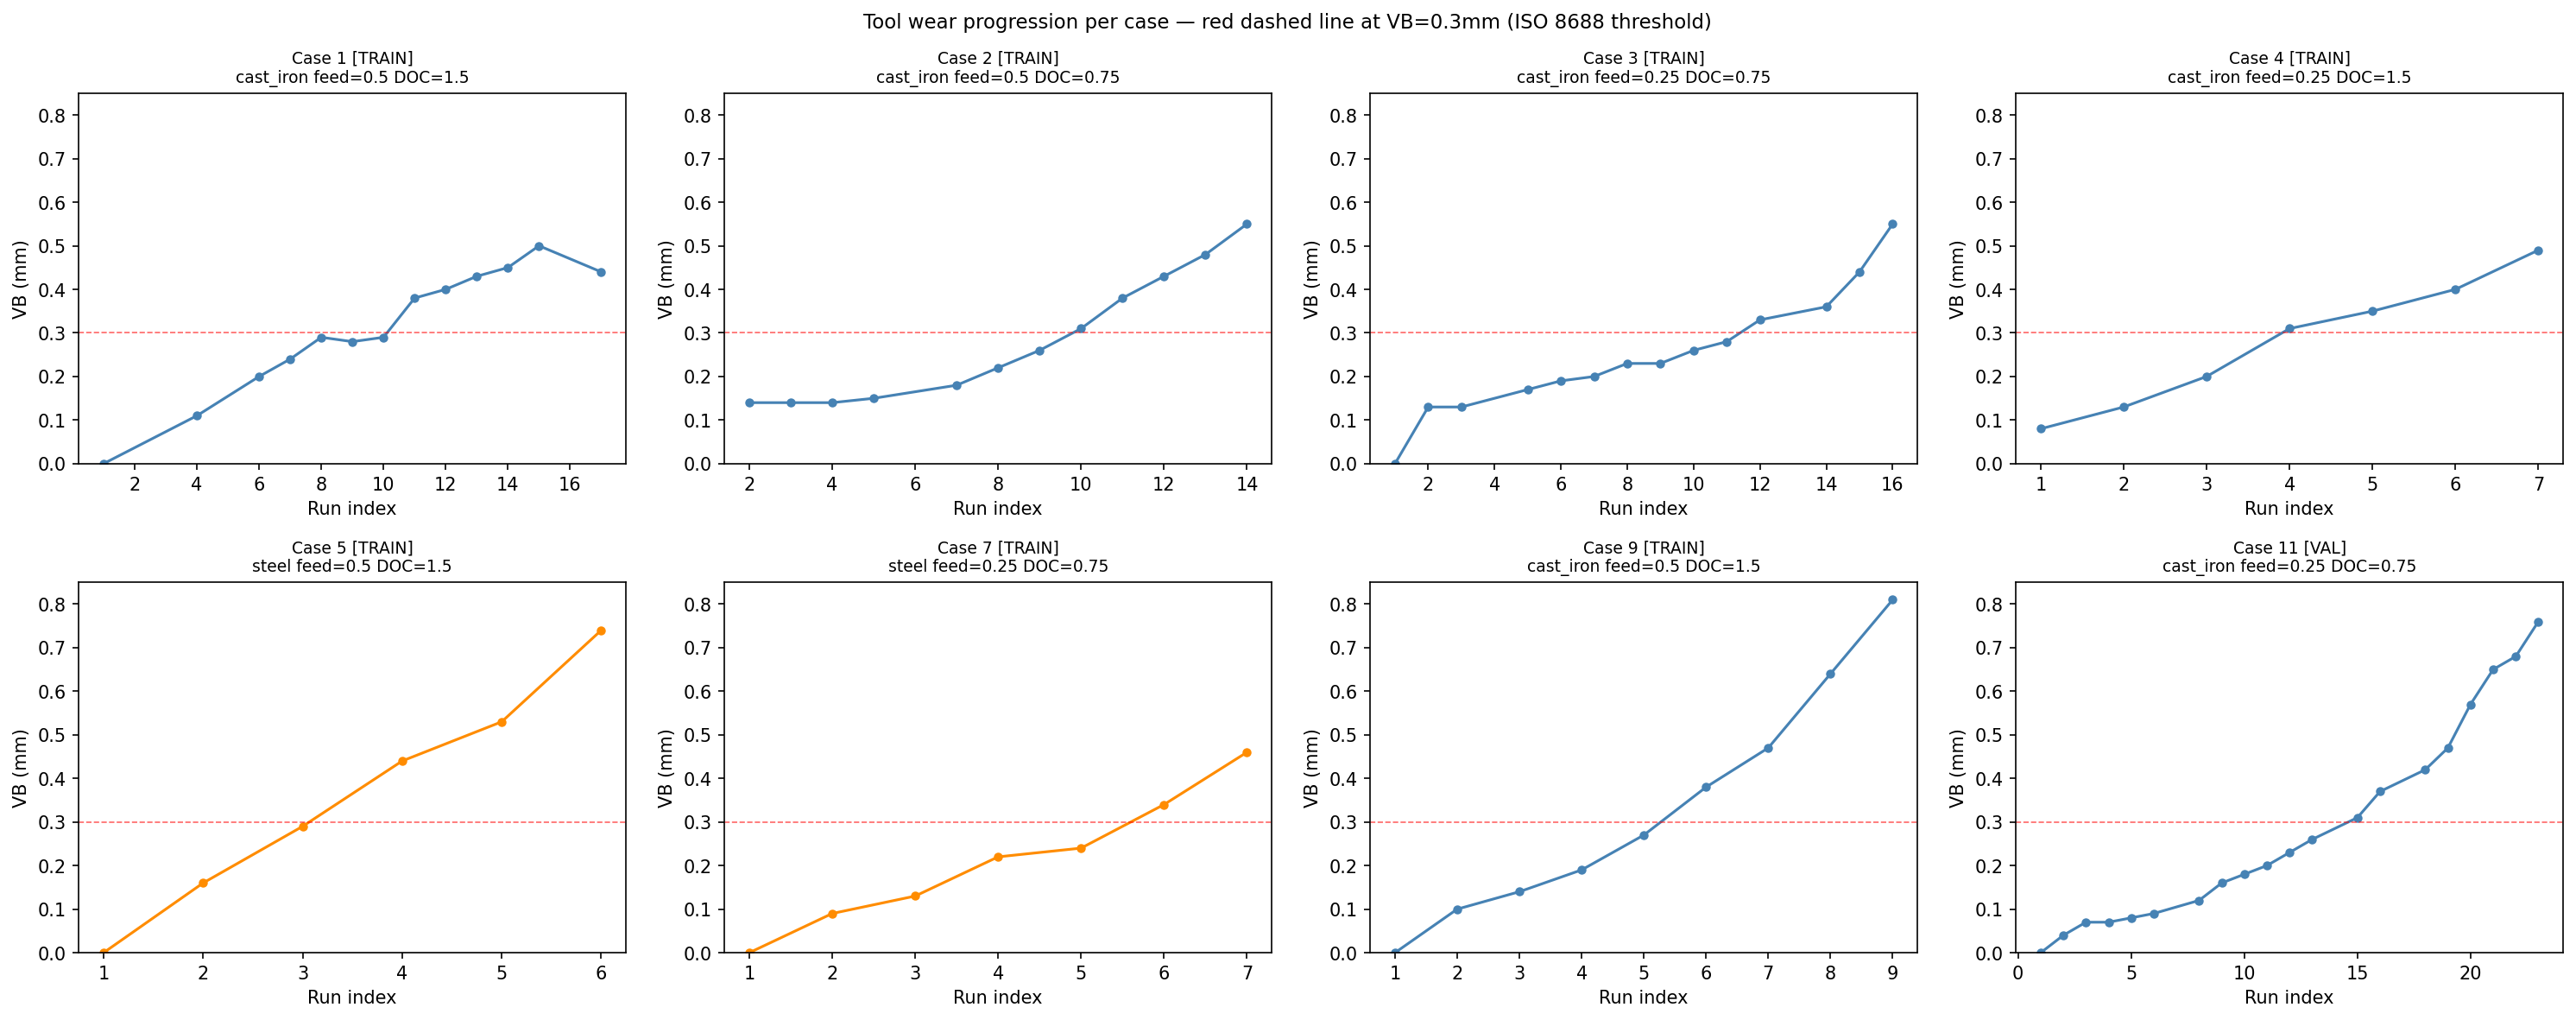


--- EDA — Raw signals: cast iron vs steel ---


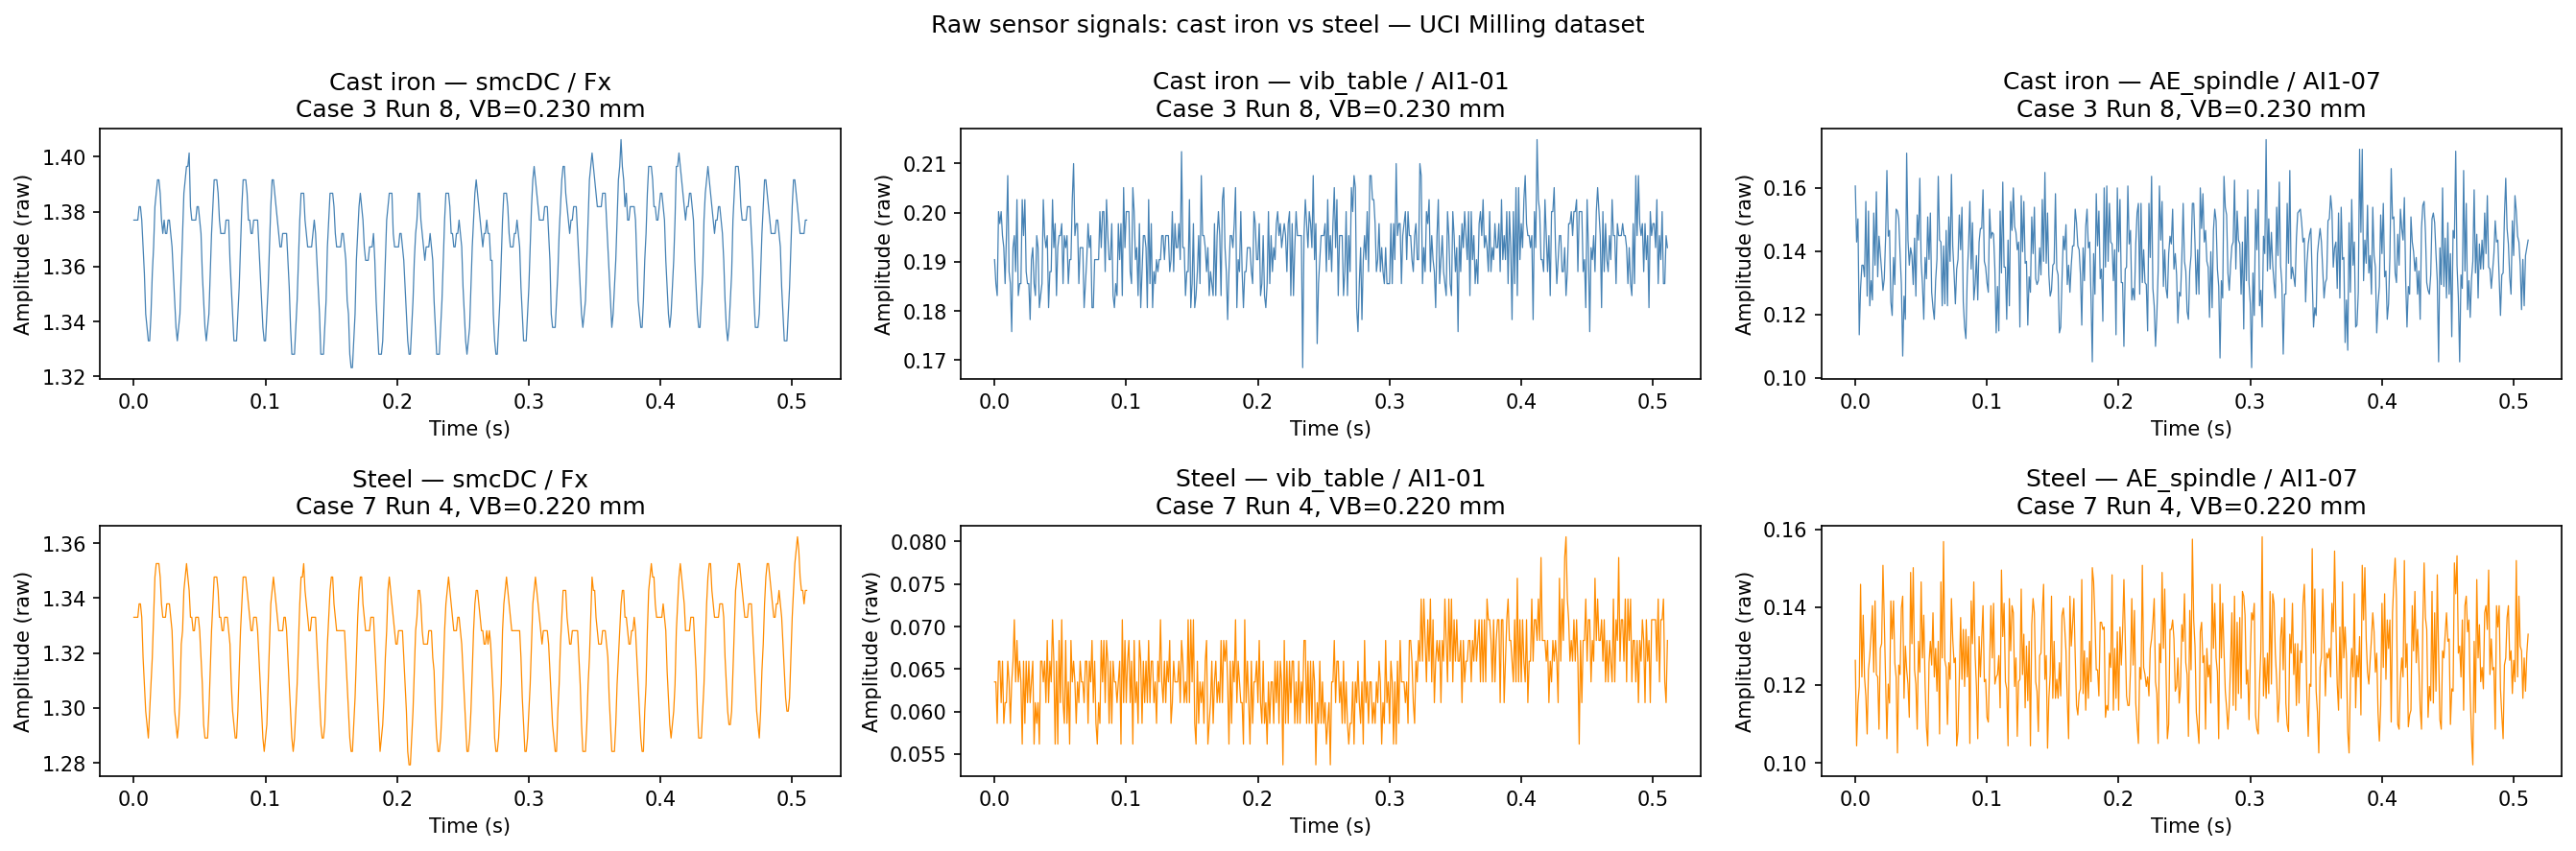


--- EDA — Channel correlation heatmap ---


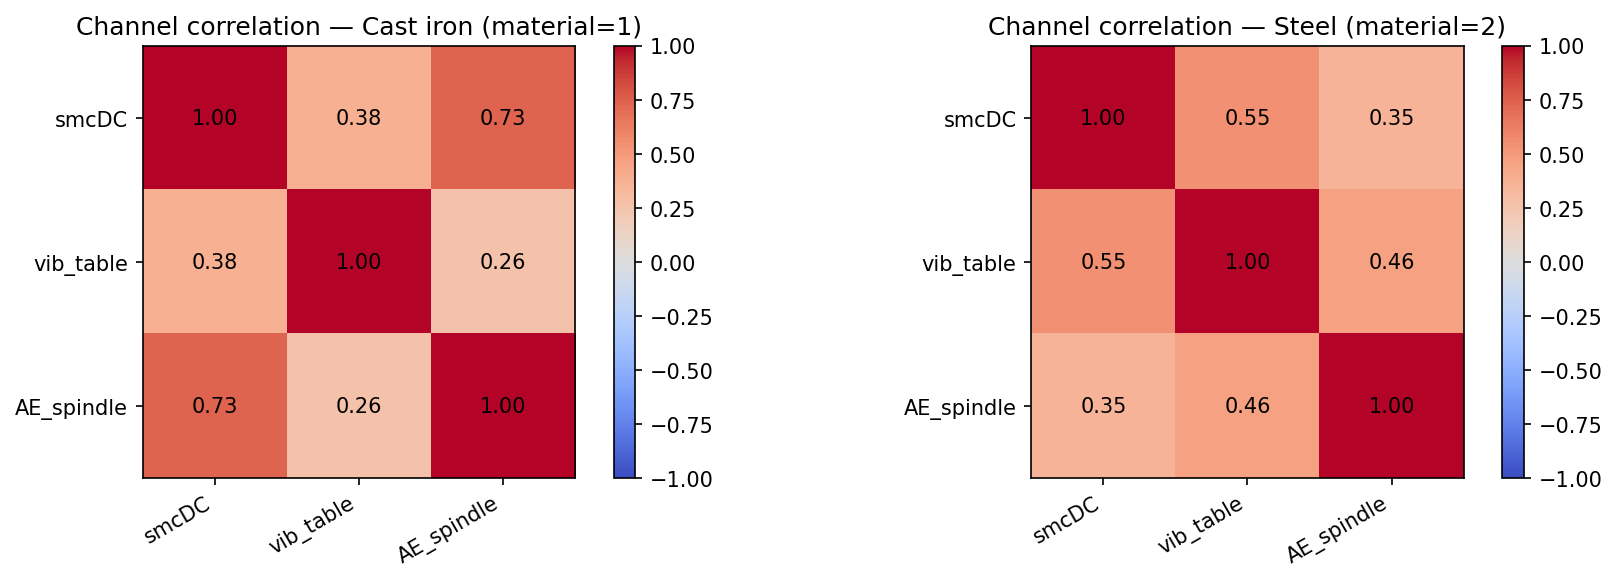


--- EDA — VB label distribution by split ---


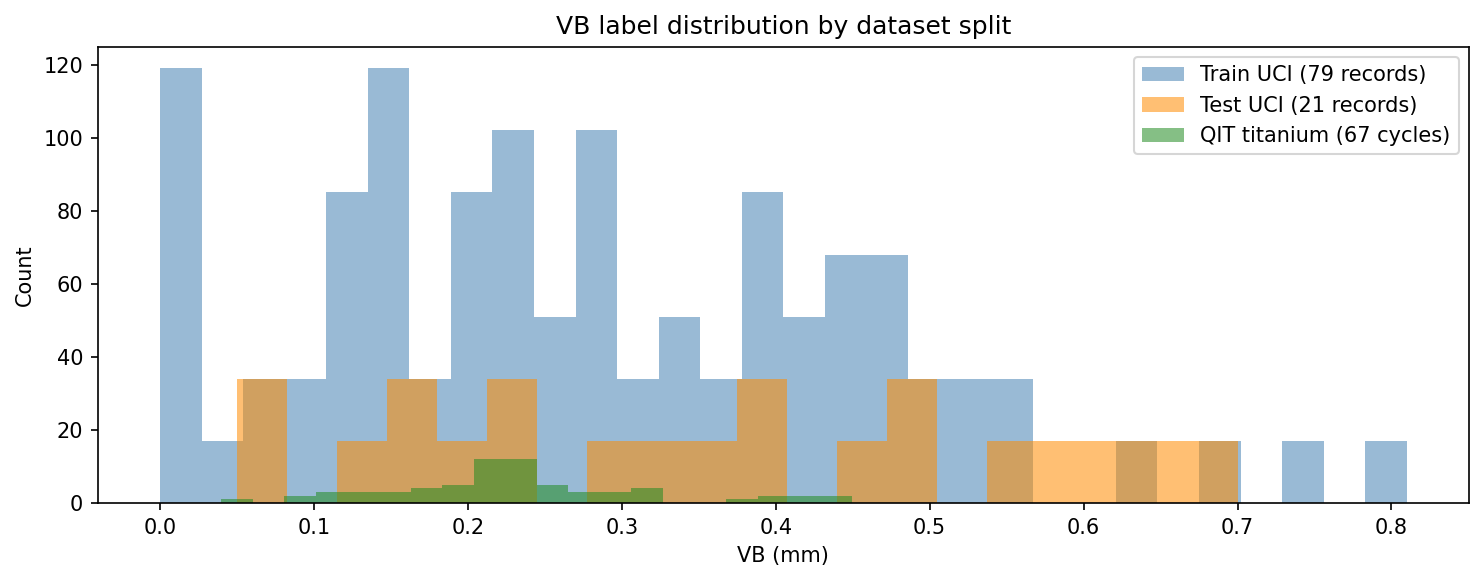


--- Training — Loss and validation R2 ---


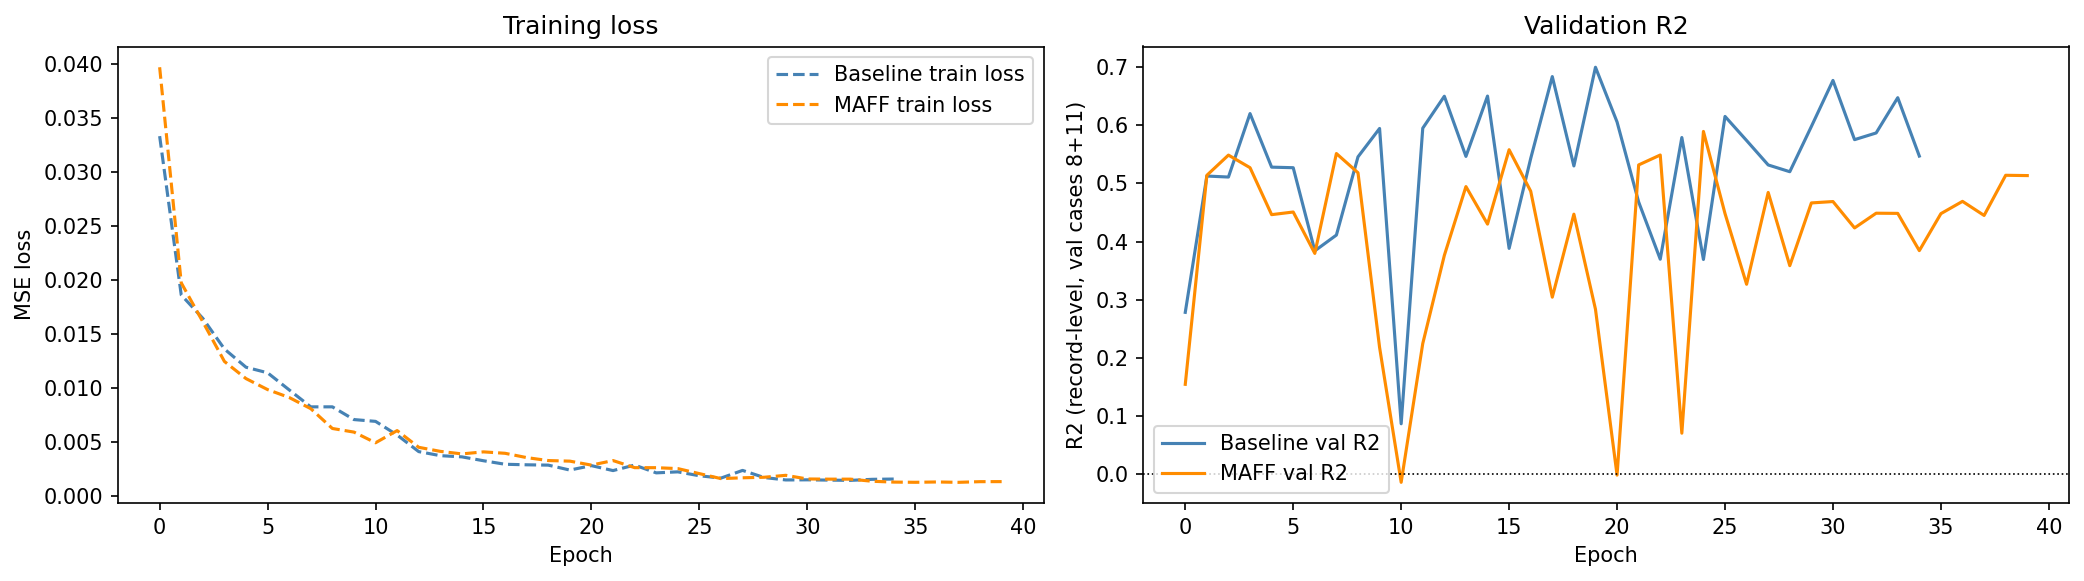


--- Results — Predicted vs True VB ---


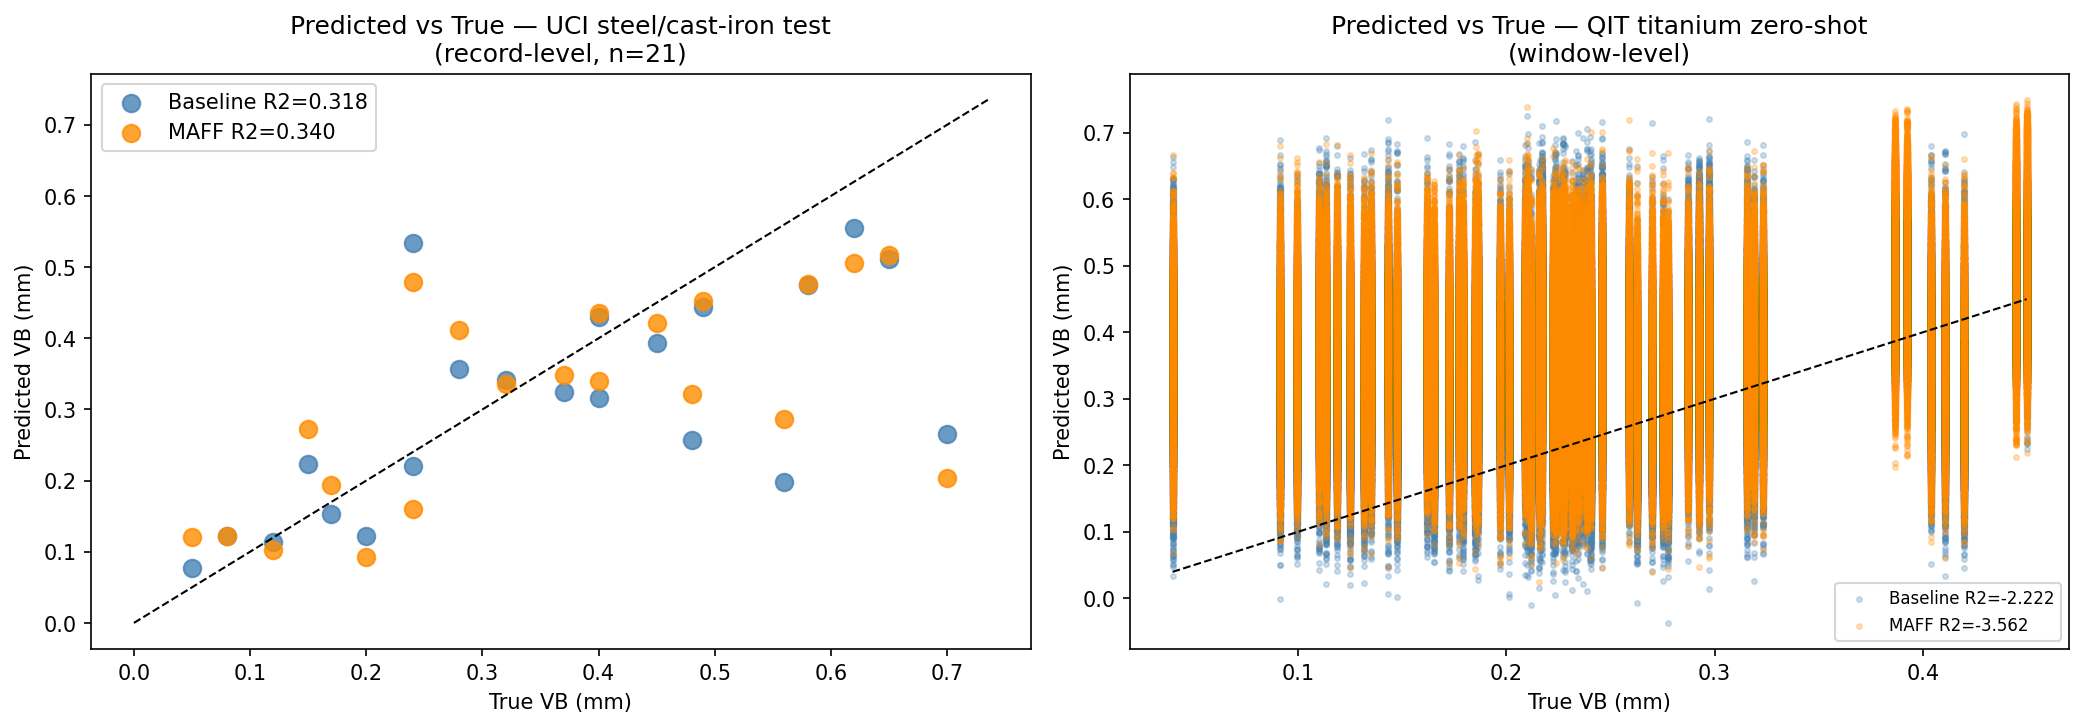


--- Results — Bland-Altman agreement (steel test) ---


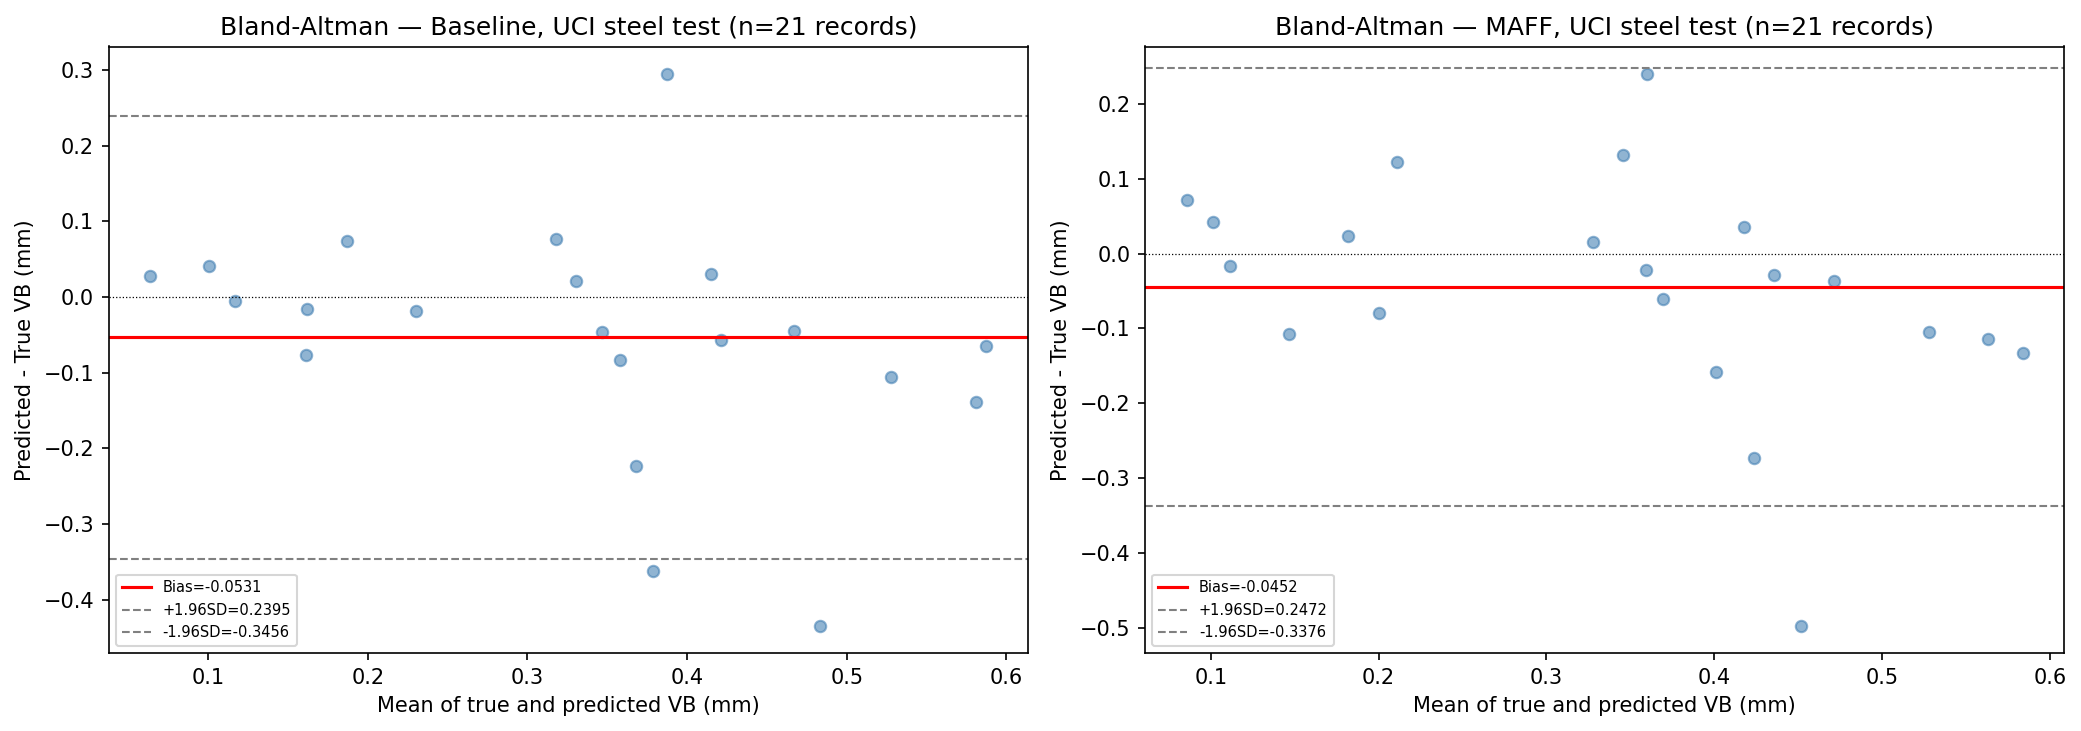


--- Results — Residual distributions ---


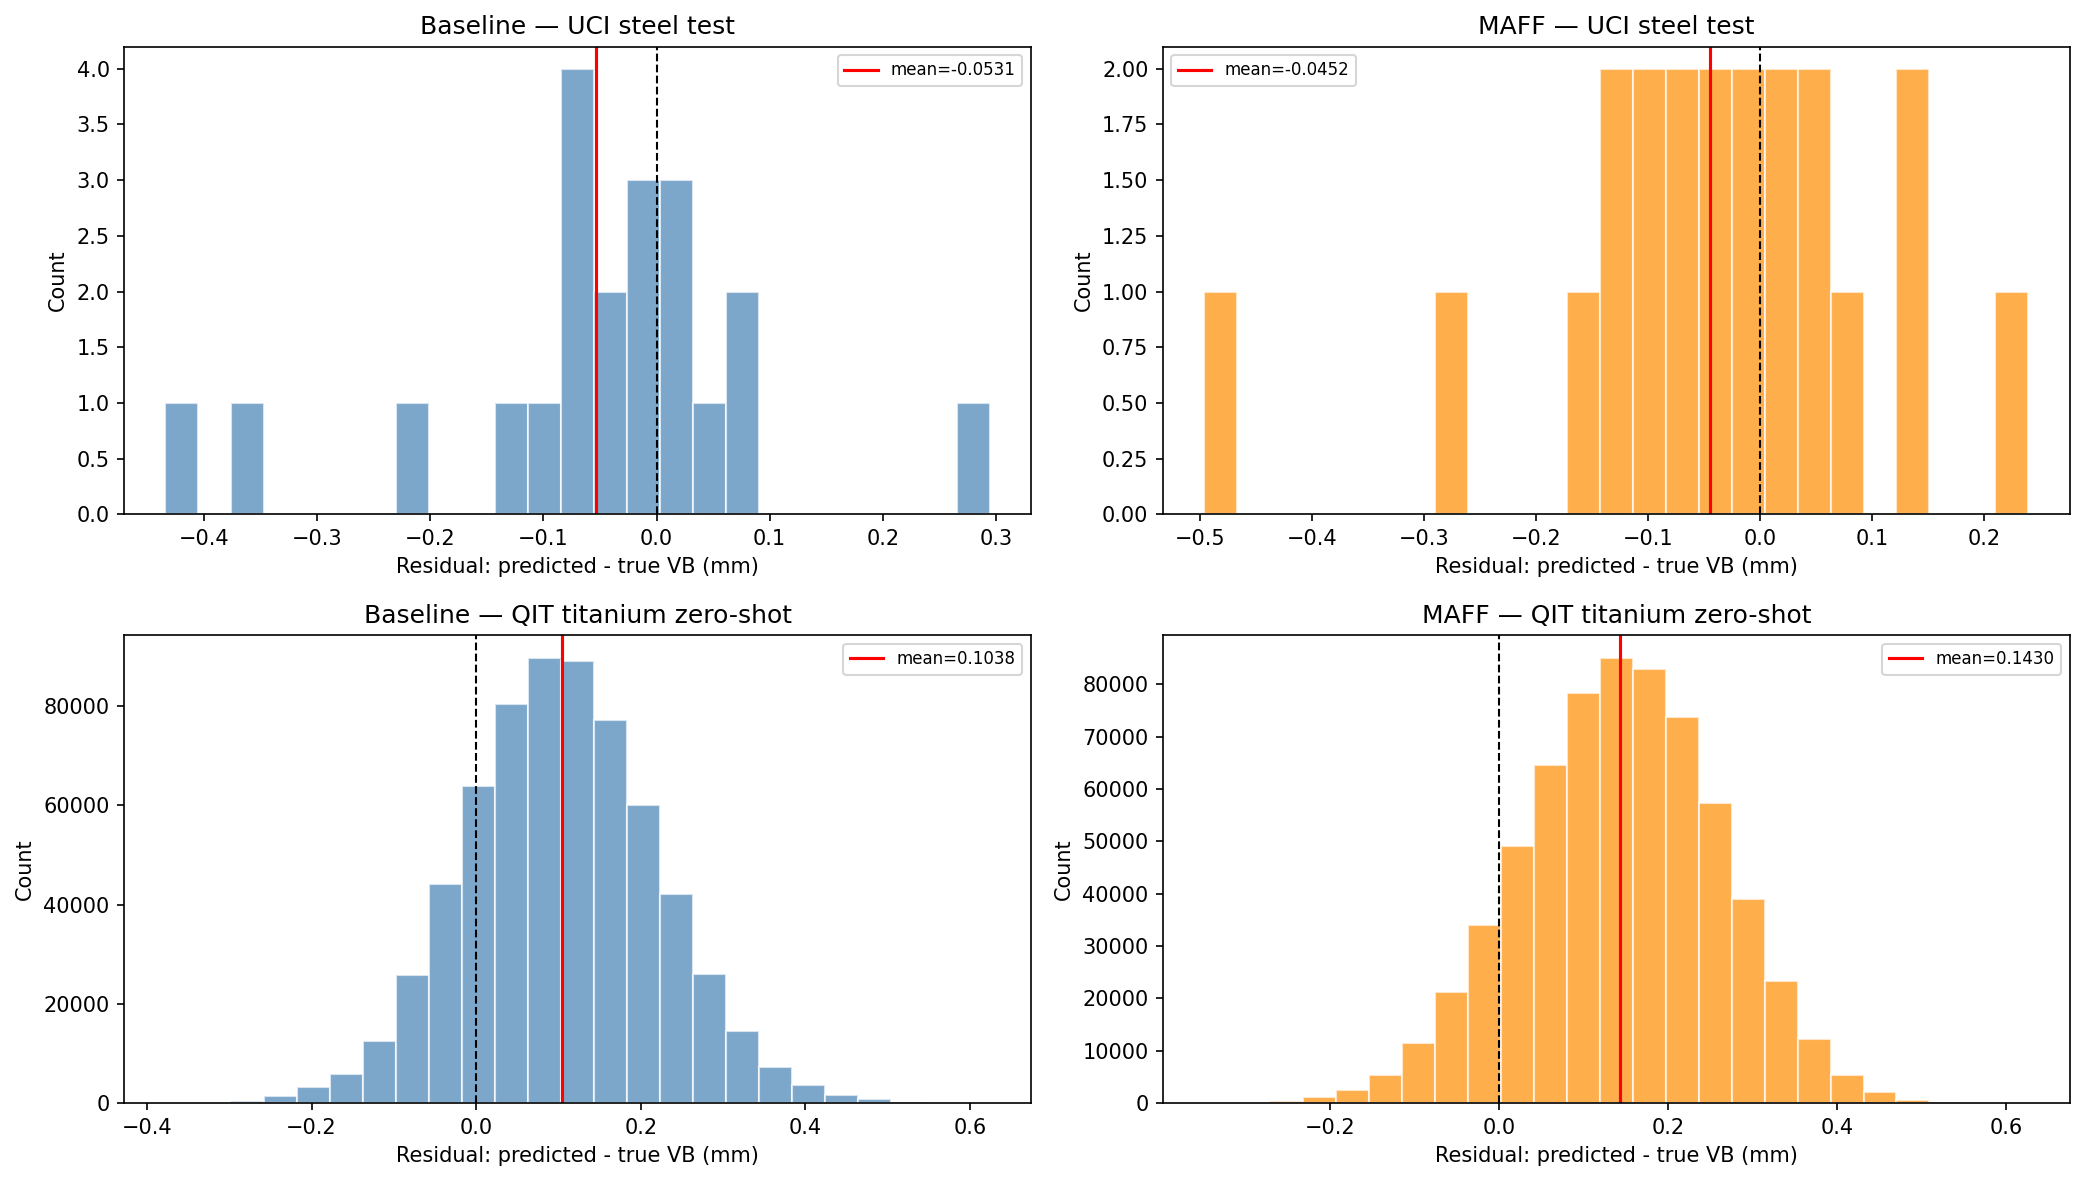


--- Results — Signal ablation R2 ---


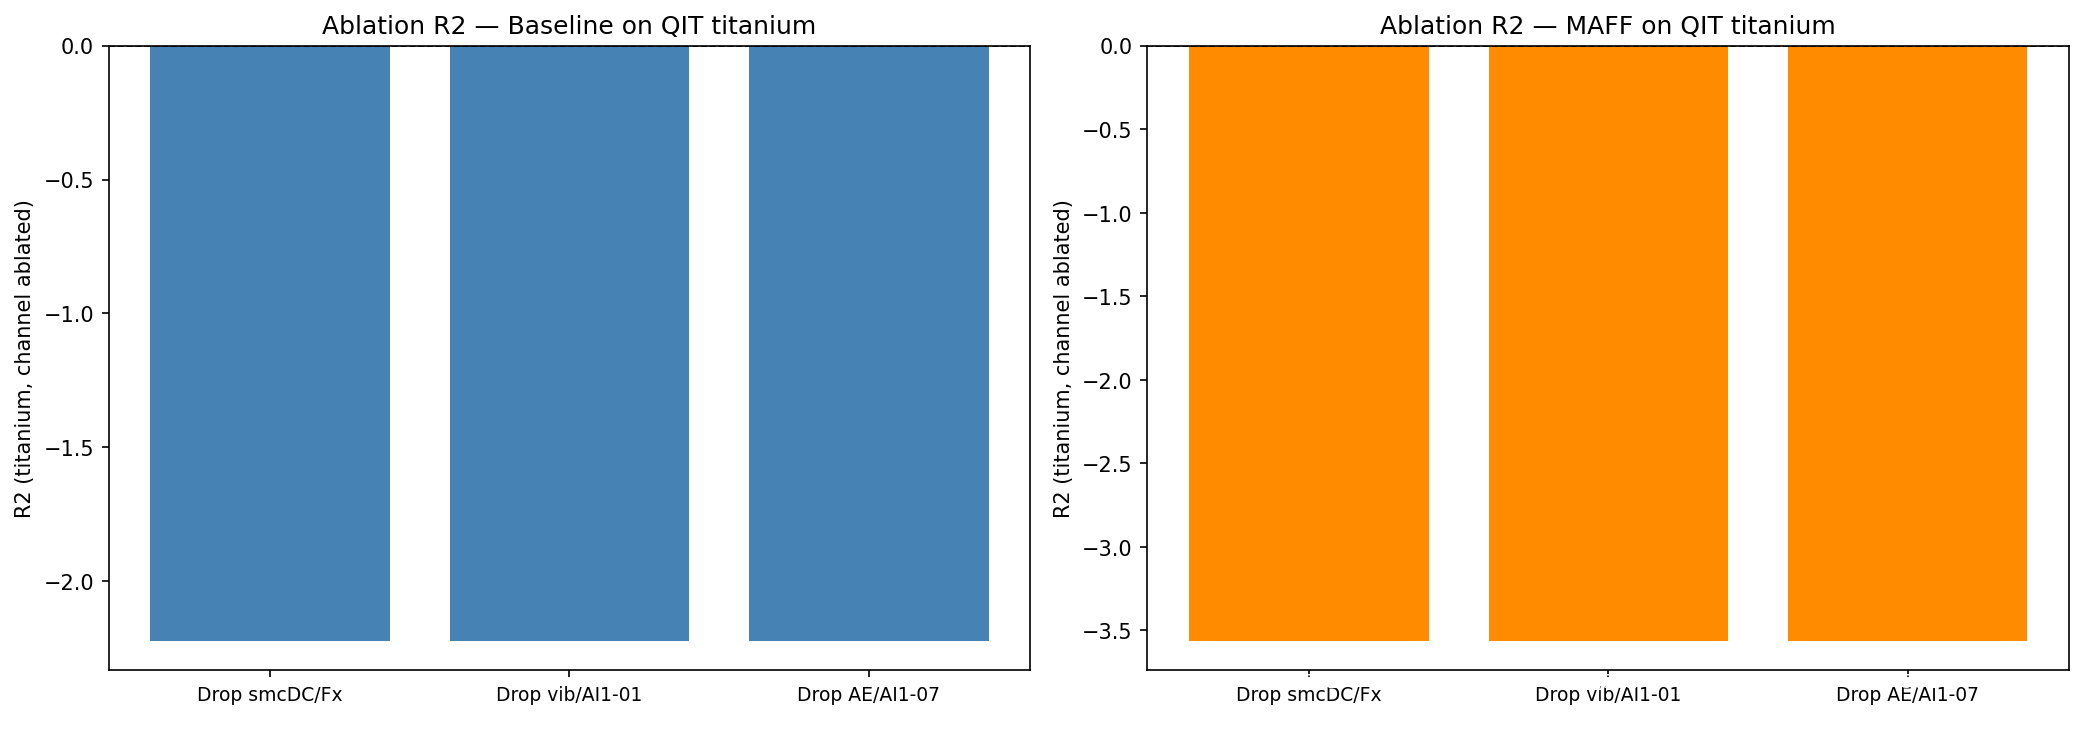


--- Results — Zero-shot vs few-shot comparison ---


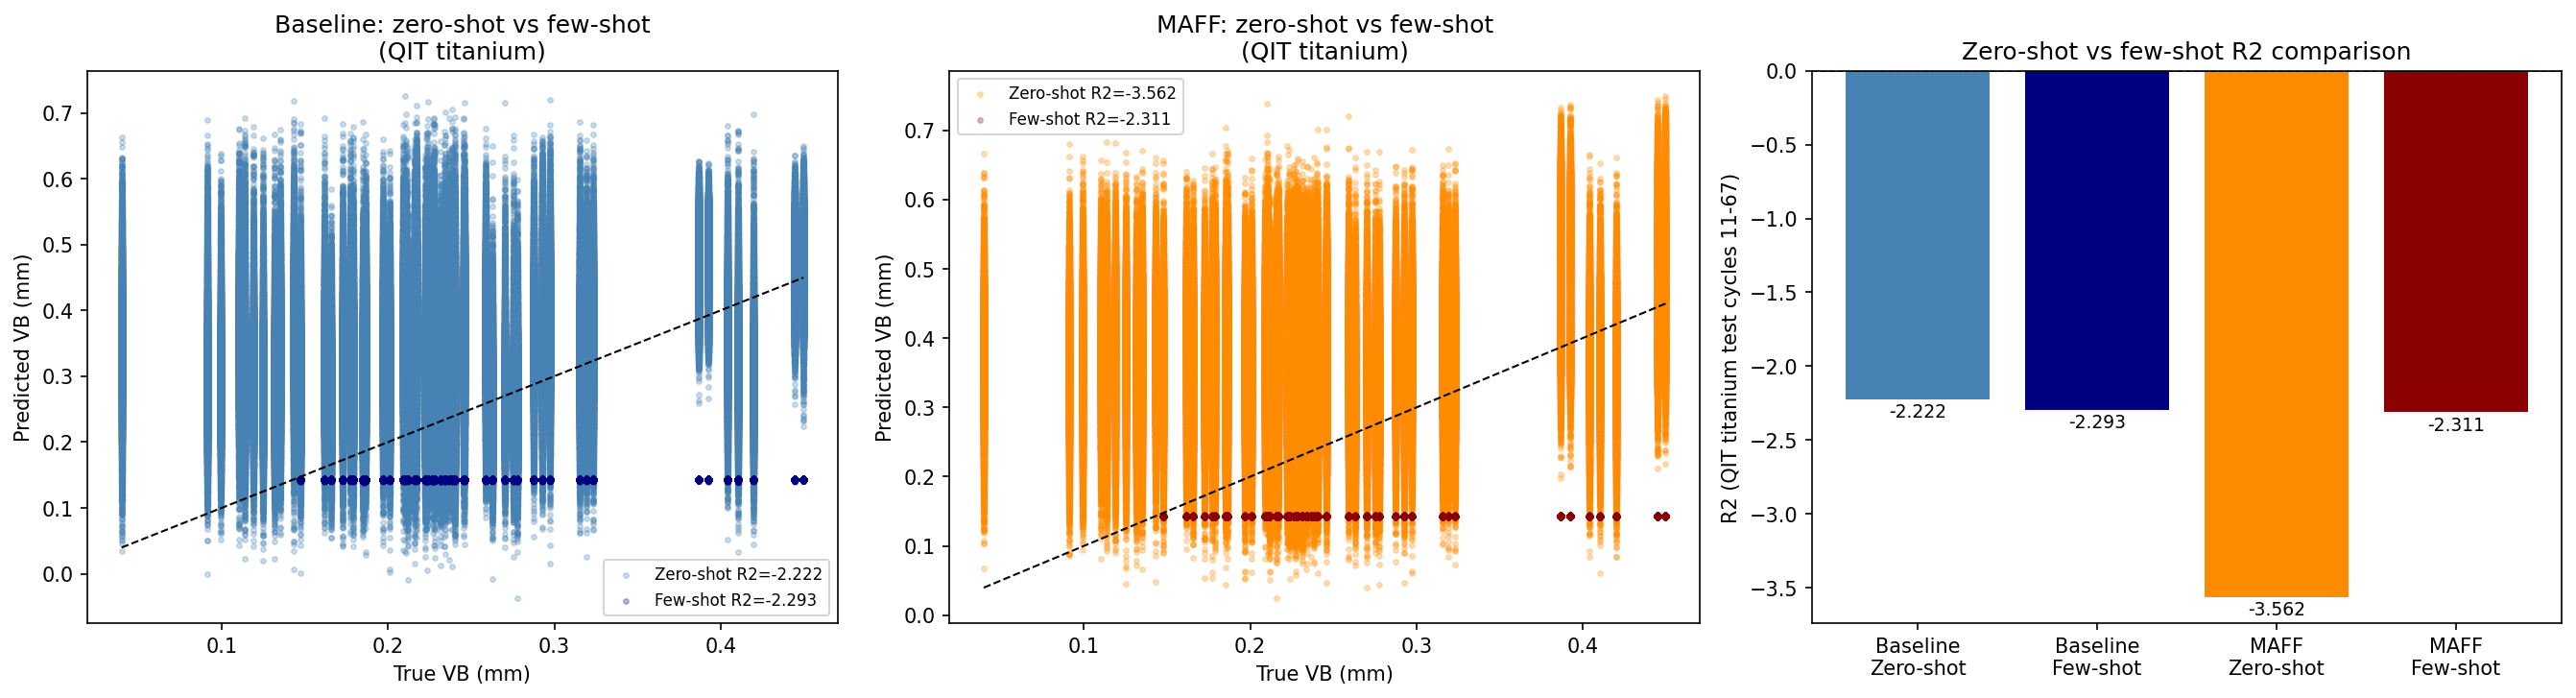

In [81]:
from IPython.display import display, Image

plots = [
    ('eda_wear_curves.png',          'EDA — Wear progression curves per case'),
    ('eda_raw_signals_uci.png',      'EDA — Raw signals: cast iron vs steel'),
    ('eda_channel_correlation.png',  'EDA — Channel correlation heatmap'),
    ('eda_vb_distribution.png',      'EDA — VB label distribution by split'),
    ('plot_training_curves.png',     'Training — Loss and validation R2'),
    ('plot_pred_vs_true.png',        'Results — Predicted vs True VB'),
    ('plot_bland_altman_steel.png',  'Results — Bland-Altman agreement (steel test)'),
    ('plot_residuals.png',           'Results — Residual distributions'),
    ('plot_ablation.png',            'Results — Signal ablation R2'),
    ('plot_fewshot.png',             'Results — Zero-shot vs few-shot comparison'),
]

for filename, title in plots:
    print(f'\n--- {title} ---')
    display(Image(filename=filename))